# Empirical ideology dynamics: linear and nonlinear Fokker–Planck models

**Voteview DW-NOMINATE scores → Congress-level ideology density → linear FP/PINN baseline → nonlinear nonlocal FP interaction model → forward out-of-sample forecast**

This notebook starts from Voteview's longitudinal first-dimension NOMINATE scores for House members in Congresses 79–118, converts the member-level ideology coordinates into a Congress-by-Congress density panel, and then fits two dynamical models to the same chronological training sample.

1. **Linear baseline:** learn a time-homogeneous drift $b(x)$ with a PINN and solve the linear Fokker–Planck equation forward.
2. **Nonlinear extension:** learn a distribution-dependent drift

   $$b[p](t,x) = b_ext(x) + \int K(x-y) p(t,y) dy$$

   and solve the resulting nonlinear/nonlocal Fokker–Planck equation forward from the last training Congress.

The nonlinear model is the direct PDE extension of the "ideology landscape" idea: the future motion of ideological mass depends not only on where it currently sits, but also on the current population distribution itself.

The current notebook still uses Voteview's already-estimated longitudinal $nominate_dim1$ values as the upstream $X_{i,t}$ input. The attached longitudinal DW-NOMINATE walkthrough explains how those session-specific positions can instead be estimated jointly from raw roll-call votes through legislator trajectories $X_it = chi_i0 + chi_i1 T_t1$. Replacing the Voteview score-loading block with that raw-vote estimator would not change any of the KDE or PDE sections below.

Main pipeline:

$$roll-call-based X_{i,t} → p_obs(t,x) → [linear baseline | nonlinear b[p]] → forward p_hat(t,x) → held-out Congress comparison$$

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.ndimage import gaussian_filter
from scipy.integrate import cumulative_trapezoid
from scipy.stats import norm

# ------------------------------------------------------------
# Empirical data configuration
# ------------------------------------------------------------
CHAMBER = "House"
MIN_CONGRESS = 79
MAX_CONGRESS = 118

VOTEVIEW_MEMBERS_URL = (
    "https://voteview.com/static/data/out/members/HSall_members.csv"
)
LOCAL_MEMBERS_CACHE = Path("HSall_members.csv")

# Download once, then reuse the local copy on later runs.
if LOCAL_MEMBERS_CACHE.exists():
    members_raw = pd.read_csv(LOCAL_MEMBERS_CACHE)
    print(f"Loaded cached Voteview member data: {LOCAL_MEMBERS_CACHE}")
else:
    members_raw = pd.read_csv(VOTEVIEW_MEMBERS_URL)
    members_raw.to_csv(LOCAL_MEMBERS_CACHE, index=False)
    print(f"Downloaded Voteview member data and cached: {LOCAL_MEMBERS_CACHE}")

required_columns = {
    "congress",
    "chamber",
    "icpsr",
    "nominate_dim1",
}
missing_columns = required_columns.difference(members_raw.columns)
if missing_columns:
    raise ValueError(
        "Voteview member file is missing required columns: "
        + ", ".join(sorted(missing_columns))
    )

members = members_raw.loc[
    (members_raw["chamber"] == CHAMBER)
    & (members_raw["congress"].between(MIN_CONGRESS, MAX_CONGRESS)),
].copy()

members["nominate_dim1"] = pd.to_numeric(
    members["nominate_dim1"], errors="coerce"
)
members = members.dropna(subset=["nominate_dim1"])

# NOMINATE dimension 1 is expected to live on approximately [-1, 1].
if (members["nominate_dim1"].abs() > 1.000001).any():
    bad = members.loc[
        members["nominate_dim1"].abs() > 1.000001,
        ["congress", "icpsr", "nominate_dim1"],
    ].head()
    raise ValueError(
        "Found nominate_dim1 values outside [-1,1]. Example rows:\n"
        + bad.to_string(index=False)
    )

scores_by_congress = {
    int(congress): group["nominate_dim1"].to_numpy(dtype=float)
    for congress, group in members.groupby("congress", sort=True)
}

expected_congresses = set(range(MIN_CONGRESS, MAX_CONGRESS + 1))
missing_congresses = sorted(
    expected_congresses.difference(scores_by_congress)
)
if missing_congresses:
    raise ValueError(
        f"Missing Congresses after filtering: {missing_congresses}"
    )

counts = pd.Series(
    {c: len(v) for c, v in scores_by_congress.items()},
    name="n_scored_members",
)

print(f"\nChamber: {CHAMBER}")
print(f"Congresses: {MIN_CONGRESS}–{MAX_CONGRESS}")
print(f"Number of Congresses: {len(scores_by_congress)}")
print(
    "Scored members per Congress: "
    f"min={counts.min()}, median={counts.median():.0f}, max={counts.max()}"
)
print(
    "Overall nominate_dim1 range: "
    f"[{members['nominate_dim1'].min():.3f}, "
    f"{members['nominate_dim1'].max():.3f}]"
)

display(
    members[
        [c for c in [
            "congress", "icpsr", "bioname", "party_code", "nominate_dim1"
        ] if c in members.columns]
    ].head()
)


Downloaded Voteview member data and cached: HSall_members.csv

Chamber: House
Congresses: 79–118
Number of Congresses: 40
Scored members per Congress: min=438, median=444, max=455
Overall nominate_dim1 range: [-1.000, 0.955]


,congress,icpsr,bioname,party_code,nominate_dim1
28575,79,195,"ANDREWS, George William",100.0,-0.030
28576,79,937,"BOYKIN, Frank William",100.0,-0.105
28577,79,3754,"GRANT, George McInvale",100.0,-0.117
28578,79,4471,"HOBBS, Samuel Francis",100.0,-0.176
28579,79,4892,"JARMAN, Peterson Bryant (Pete)",100.0,-0.238


In [2]:
def reflected_kde(
    scores,
    x_grid,
    bandwidth=None,
    lower=-1.0,
    upper=1.0,
):
    """
    Reflected Gaussian KDE on [lower, upper].

    Formula:

        p_hat(t,x)
        = (1 / (N_t h)) sum_i [
              phi((x - X_i)/h)
            + phi((x - (2L - X_i))/h)
            + phi((x - (2U - X_i))/h)
          ]

    The final density is normalized so that

        integral_{-1}^{1} p_hat(t,x) dx = 1.
    """
    scores = np.asarray(scores, dtype=float)
    scores = scores[np.isfinite(scores)]

    if len(scores) == 0:
        raise ValueError("No valid ideology scores were supplied.")

    if np.any((scores < lower) | (scores > upper)):
        raise ValueError(
            f"All ideology scores must lie in [{lower}, {upper}]."
        )

    n = len(scores)

    # Automatic bandwidth
    if bandwidth is None:
        if n == 1:
            scale = 0.10
        else:
            sd = np.std(scores, ddof=1)

            q25, q75 = np.percentile(scores, [25, 75])
            robust_sd = (q75 - q25) / 1.349

            valid_scales = [
                value
                for value in (sd, robust_sd)
                if np.isfinite(value) and value > 0
            ]

            scale = min(valid_scales) if valid_scales else 0.10

        bandwidth = max(
            0.9 * scale * n ** (-1.0 / 5.0),
            0.025,
        )

    # Original locations
    z_original = (
        x_grid[:, None] - scores[None, :]
    ) / bandwidth

    # Reflection across x = lower
    reflected_lower = 2.0 * lower - scores

    z_lower = (
        x_grid[:, None] - reflected_lower[None, :]
    ) / bandwidth

    # Reflection across x = upper
    reflected_upper = 2.0 * upper - scores

    z_upper = (
        x_grid[:, None] - reflected_upper[None, :]
    ) / bandwidth

    # Reflected KDE formula
    density = (
        norm.pdf(z_original)
        + norm.pdf(z_lower)
        + norm.pdf(z_upper)
    ).sum(axis=1) / (n * bandwidth)

    density = np.maximum(density, 0.0)

    # Normalize to unit mass
    mass = np.trapezoid(density, x_grid)

    if not np.isfinite(mass) or mass <= 0:
        raise RuntimeError("KDE normalization failed.")

    density = density / mass

    return density


def build_density_panel(
    scores_by_congress,
    nx=401,
    bandwidth=None,
):
    """
    Convert Congress-indexed ideology scores into p(t,x).

    Input
    -----
    scores_by_congress:
        {
            congress_number: np.array([...]),
            ...
        }

    Output
    ------
    congresses:
        Original Congress numbers.

    t:
        Congress time normalized to [0,1].

    x_grid:
        Ideology grid in [-1,1].

    p:
        Density array with shape
        (number_of_congresses, number_of_x_points).
    """
    congresses = np.array(
        sorted(scores_by_congress.keys()),
        dtype=float,
    )

    if len(congresses) < 3:
        raise ValueError(
            "At least three time points are needed "
            "for numerical time derivatives."
        )

    x_grid = np.linspace(-1.0, 1.0, nx)

    density_rows = []

    for congress in congresses:
        scores = scores_by_congress[int(congress)]

        density = reflected_kde(
            scores=scores,
            x_grid=x_grid,
            bandwidth=bandwidth,
        )

        density_rows.append(density)

    p = np.vstack(density_rows)

    # Congress 79 -> t=0, last Congress -> t=1
    t = (
        congresses - congresses.min()
    ) / (
        congresses.max() - congresses.min()
    )

    return congresses, t, x_grid, p

In [3]:
def infer_vanilla_fp(
    t,
    x,
    p,
    D=0.001,
    density_floor=1e-4,
    smooth_sigma_time=1.0,
    smooth_sigma_space=1.0,
):
    r"""
    Vanilla Fokker-Planck equation:

        p_t + ∂_x(b p) - D p_xx = 0

    Equivalently:

        p_t = -∂_x(b p) + D p_xx

    Probability flux:

        J = b p - D p_x

    No-flux boundary condition:

        J(t,-1) = J(t,1) = 0

    Inverse drift formula from the left no-flux boundary:

        b(t,x)
        =
        [D p_x(t,x) - integral_{-1}^{x} p_t(t,y)dy]
        / p(t,x)
    """
    t = np.asarray(t, dtype=float)
    x = np.asarray(x, dtype=float)
    p = np.asarray(p, dtype=float)

    if p.shape != (len(t), len(x)):
        raise ValueError(
            "p must have shape (len(t), len(x))."
        )

    if D < 0:
        raise ValueError("D must be nonnegative.")

    # --------------------------------------------------------
    # 1. Smooth p before differentiation
    #
    # Numerical differentiation amplifies KDE and sampling noise.
    # sigma_time smooths across Congresses.
    # sigma_space smooths across ideology.
    # --------------------------------------------------------
    if smooth_sigma_time > 0 or smooth_sigma_space > 0:
        p_smooth = gaussian_filter(
            p,
            sigma=(
                smooth_sigma_time,
                smooth_sigma_space,
            ),
            mode="nearest",
        )
    else:
        p_smooth = p.copy()

    p_smooth = np.maximum(p_smooth, 0.0)

    # Renormalize every time slice
    mass_before = np.trapezoid(
        p_smooth,
        x,
        axis=1,
    )

    p_smooth = (
        p_smooth
        / mass_before[:, None]
    )

    # --------------------------------------------------------
    # 2. p_t = ∂p/∂t
    # --------------------------------------------------------
    p_t = np.gradient(
        p_smooth,
        t,
        axis=0,
        edge_order=2,
    )

    # --------------------------------------------------------
    # 3. p_x = ∂p/∂x
    # --------------------------------------------------------
    p_x = np.gradient(
        p_smooth,
        x,
        axis=1,
        edge_order=2,
    )

    # --------------------------------------------------------
    # 4. p_xx = ∂²p/∂x²
    # --------------------------------------------------------
    p_xx = np.gradient(
        p_x,
        x,
        axis=1,
        edge_order=2,
    )

    # --------------------------------------------------------
    # 5. I(t,x) = integral_{-1}^{x} p_t(t,y) dy
    # --------------------------------------------------------
    integral_pt = cumulative_trapezoid(
        p_t,
        x,
        axis=1,
        initial=0.0,
    )

    # --------------------------------------------------------
    # 6. Inverse drift:
    #
    # b(t,x) = [D p_x - integral p_t] / p
    # --------------------------------------------------------
    safe_p = np.maximum(
        p_smooth,
        density_floor,
    )

    drift_raw = (
        D * p_x
        - integral_pt
    ) / safe_p

    # Regions with extremely small density are unreliable
    reliable_mask = (
        p_smooth >= density_floor
    )

    drift = np.where(
        reliable_mask,
        drift_raw,
        np.nan,
    )

    # --------------------------------------------------------
    # 7. Flux:
    #
    # J = b p - D p_x
    # --------------------------------------------------------
    flux = (
        drift_raw * p_smooth
        - D * p_x
    )

    # --------------------------------------------------------
    # 8. FP residual:
    #
    # R_FP = p_t + ∂_x(bp) - D p_xx
    # --------------------------------------------------------
    bp = drift_raw * p_smooth

    bp_x = np.gradient(
        bp,
        x,
        axis=1,
        edge_order=2,
    )

    fp_residual = (
        p_t
        + bp_x
        - D * p_xx
    )

    # --------------------------------------------------------
    # 9. Diagnostics
    # --------------------------------------------------------
    mass = np.trapezoid(
        p_smooth,
        x,
        axis=1,
    )

    fp_mse = np.nanmean(
        fp_residual**2
    )

    diagnostics = {
        "D": D,
        "max_mass_error": float(
            np.max(np.abs(mass - 1.0))
        ),
        "fp_residual_mse": float(fp_mse),
        "max_left_boundary_flux": float(
            np.max(np.abs(flux[:, 0]))
        ),
        "max_right_boundary_flux": float(
            np.max(np.abs(flux[:, -1]))
        ),
        "reliable_grid_fraction": float(
            np.mean(reliable_mask)
        ),
    }

    return {
        "p": p_smooth,
        "p_t": p_t,
        "p_x": p_x,
        "p_xx": p_xx,
        "integral_pt": integral_pt,
        "drift": drift,
        "drift_raw": drift_raw,
        "flux": flux,
        "fp_residual": fp_residual,
        "reliable_mask": reliable_mask,
        "diagnostics": diagnostics,
    }

In [4]:
congresses, t, x_grid, p = build_density_panel(
    scores_by_congress=scores_by_congress,
    nx=401,
    bandwidth=None,
)

fp_result = infer_vanilla_fp(
    t=t,
    x=x_grid,
    p=p,
    D=0.001,
    density_floor=1e-4,
    smooth_sigma_time=1.0,
    smooth_sigma_space=1.0,
)

p_smooth = fp_result["p"]
drift = fp_result["drift"]
fp_residual = fp_result["fp_residual"]
flux = fp_result["flux"]

print("p shape:", p_smooth.shape)
print("drift shape:", drift.shape)

print("\nDiagnostics")
for key, value in fp_result["diagnostics"].items():
    print(f"{key:30s}: {value:.8g}")

p shape: (40, 401)
drift shape: (40, 401)

Diagnostics
D                             : 0.001
max_mass_error                : 2.220446e-16
fp_residual_mse               : 2.8961195e-07
max_left_boundary_flux        : 6.3558865e-08
max_right_boundary_flux       : 6.6400878e-15
reliable_grid_fraction        : 0.99887781


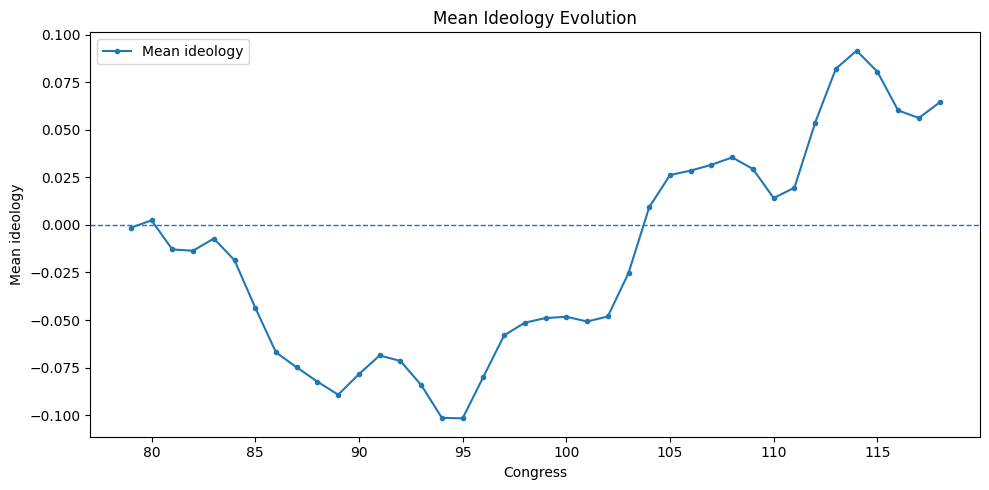

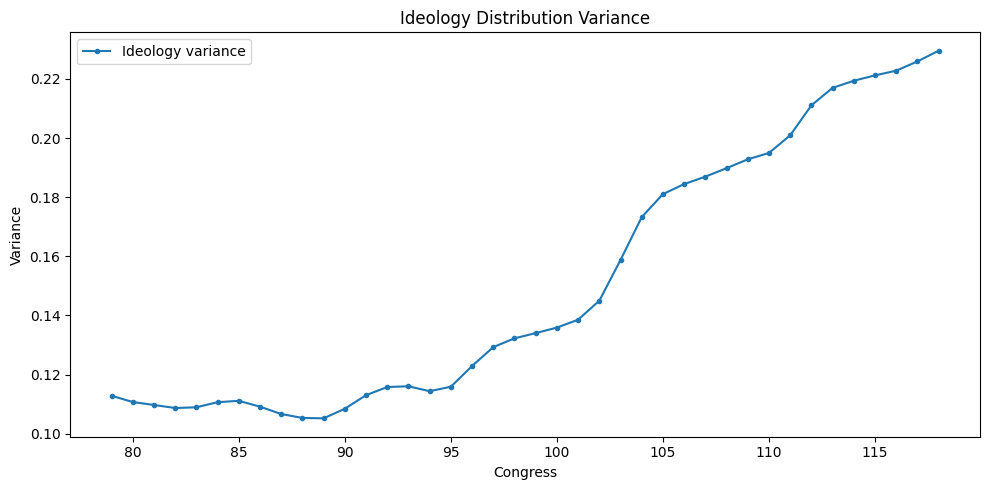

In [5]:
density_mean = np.trapezoid(
    p_smooth * x_grid[None, :],
    x_grid,
    axis=1,
)

density_second_moment = np.trapezoid(
    p_smooth * x_grid[None, :] ** 2,
    x_grid,
    axis=1,
)

density_variance = (
    density_second_moment
    - density_mean**2
)

plt.figure(figsize=(10, 5))

plt.plot(
    congresses,
    density_mean,
    marker="o",
    markersize=3,
    label="Mean ideology",
)

plt.axhline(
    0.0,
    linewidth=1,
    linestyle="--",
)

plt.xlabel("Congress")
plt.ylabel("Mean ideology")
plt.title("Mean Ideology Evolution")
plt.legend()

plt.tight_layout()
plt.show()


plt.figure(figsize=(10, 5))

plt.plot(
    congresses,
    density_variance,
    marker="o",
    markersize=3,
    label="Ideology variance",
)

plt.xlabel("Congress")
plt.ylabel("Variance")
plt.title("Ideology Distribution Variance")
plt.legend()

plt.tight_layout()
plt.show()

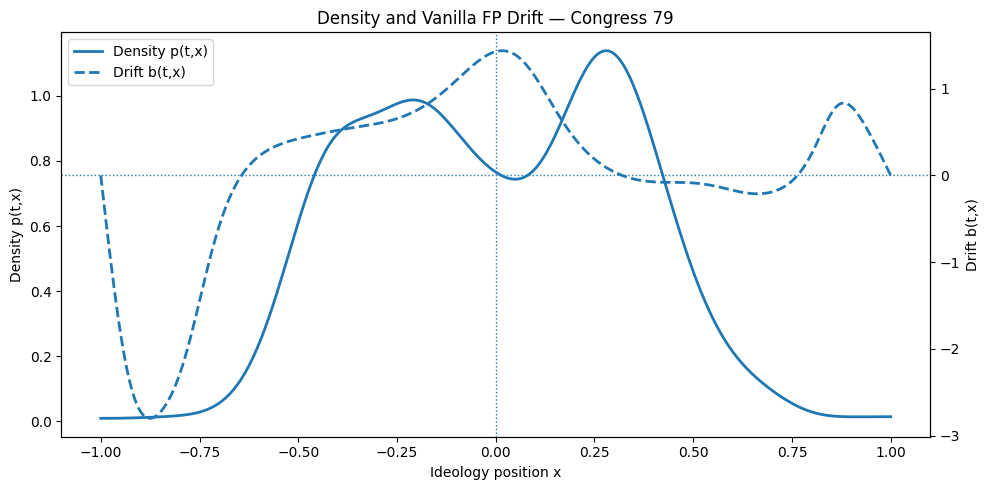

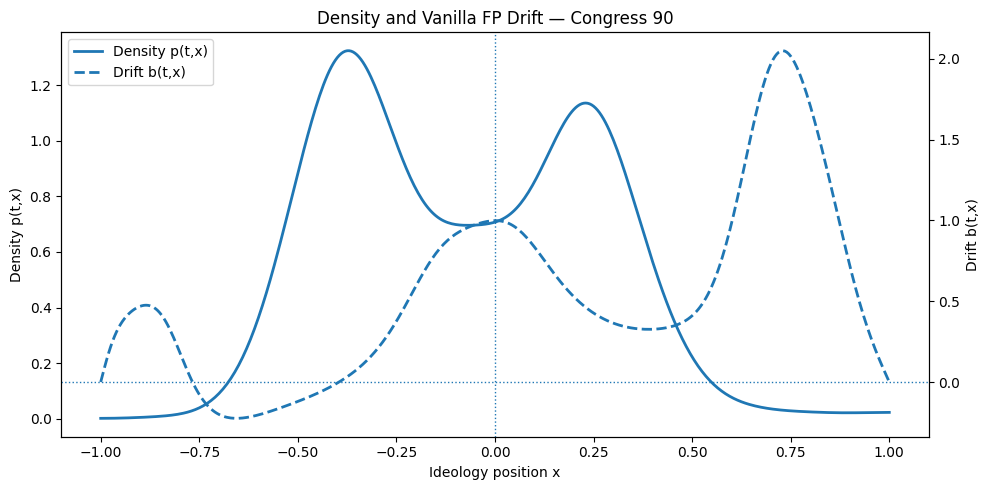

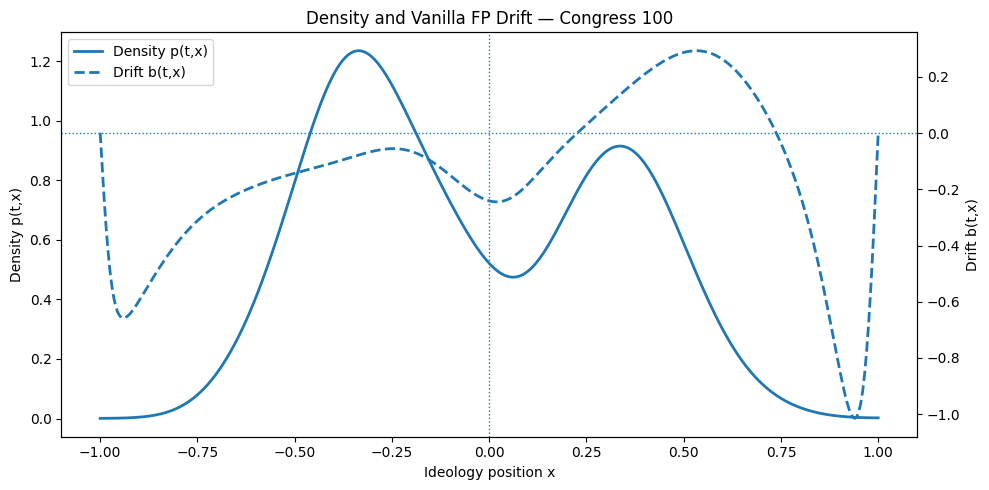

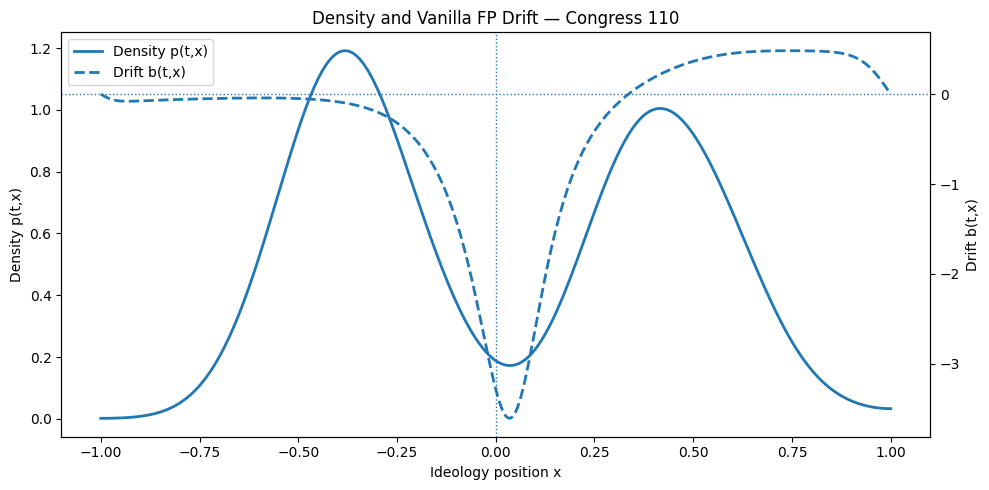

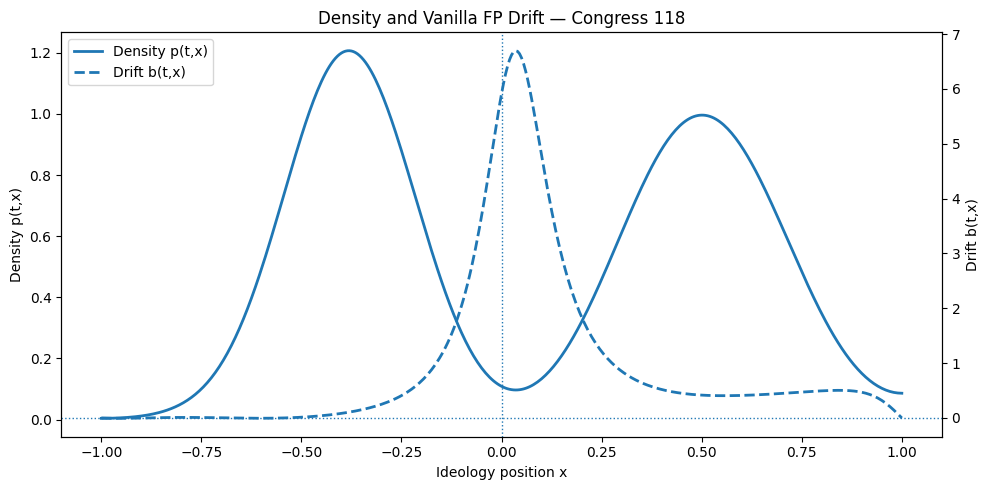

In [6]:
selected_congresses = [
    79,
    90,
    100,
    110,
    118,
]

for selected in selected_congresses:
    index = int(
        np.argmin(
            np.abs(congresses - selected)
        )
    )

    fig, density_axis = plt.subplots(
        figsize=(10, 5)
    )

    drift_axis = density_axis.twinx()

    density_axis.plot(
        x_grid,
        p_smooth[index],
        linewidth=2,
        label="Density p(t,x)",
    )

    drift_axis.plot(
        x_grid,
        drift[index],
        linewidth=2,
        linestyle="--",
        label="Drift b(t,x)",
    )

    density_axis.axvline(
        0.0,
        linewidth=1,
        linestyle=":",
    )

    drift_axis.axhline(
        0.0,
        linewidth=1,
        linestyle=":",
    )

    density_axis.set_xlabel(
        "Ideology position x"
    )

    density_axis.set_ylabel(
        "Density p(t,x)"
    )

    drift_axis.set_ylabel(
        "Drift b(t,x)"
    )

    density_axis.set_title(
        f"Density and Vanilla FP Drift — Congress {int(congresses[index])}"
    )

    density_lines, density_labels = (
        density_axis.get_legend_handles_labels()
    )

    drift_lines, drift_labels = (
        drift_axis.get_legend_handles_labels()
    )

    density_axis.legend(
        density_lines + drift_lines,
        density_labels + drift_labels,
        loc="upper left",
    )

    fig.tight_layout()
    plt.show()

----------------------------PINN----------------------------

In [7]:
import copy
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import norm

import torch
import torch.nn as nn
import torch.nn.functional as F

%matplotlib inline

# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------
SEED = 7

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

torch.set_default_dtype(torch.float32)

print("PyTorch version:", torch.__version__)
print("Device:", device)

PyTorch version: 2.11.0+cpu
Device: cpu


In [8]:
def reflected_kde(
    scores,
    x_grid,
    bandwidth=None,
    lower=-1.0,
    upper=1.0,
):
    """
    Reflected Gaussian KDE on [lower, upper].

    p_hat(x)
    =
    1/(N h) sum_i [
        phi((x-X_i)/h)
        + phi((x-(2L-X_i))/h)
        + phi((x-(2U-X_i))/h)
    ]
    """
    scores = np.asarray(scores, dtype=float)
    scores = scores[np.isfinite(scores)]

    if len(scores) == 0:
        raise ValueError("No valid ideology scores.")

    if np.any((scores < lower) | (scores > upper)):
        raise ValueError(
            f"Scores must lie in [{lower}, {upper}]."
        )

    n = len(scores)

    if bandwidth is None:
        if n == 1:
            scale = 0.10
        else:
            sd = np.std(scores, ddof=1)

            q25, q75 = np.percentile(
                scores,
                [25, 75],
            )

            robust_sd = (q75 - q25) / 1.349

            valid_scales = [
                value
                for value in (sd, robust_sd)
                if np.isfinite(value) and value > 0
            ]

            scale = (
                min(valid_scales)
                if valid_scales
                else 0.10
            )

        bandwidth = max(
            0.9 * scale * n ** (-1.0 / 5.0),
            0.025,
        )

    reflected_lower = 2.0 * lower - scores
    reflected_upper = 2.0 * upper - scores

    z_original = (
        x_grid[:, None] - scores[None, :]
    ) / bandwidth

    z_lower = (
        x_grid[:, None]
        - reflected_lower[None, :]
    ) / bandwidth

    z_upper = (
        x_grid[:, None]
        - reflected_upper[None, :]
    ) / bandwidth

    density = (
        norm.pdf(z_original)
        + norm.pdf(z_lower)
        + norm.pdf(z_upper)
    ).sum(axis=1) / (n * bandwidth)

    density = np.maximum(density, 0.0)

    mass = np.trapezoid(
        density,
        x_grid,
    )

    if not np.isfinite(mass) or mass <= 0:
        raise RuntimeError("KDE normalization failed.")

    return density / mass


def build_density_panel(
    scores_by_congress,
    nx=201,
    bandwidth=None,
):
    """
    Convert:
        {congress: array of X scores}

    into:
        congresses
        normalized times t in [0,1]
        ideology grid x
        density panel p(t,x)
    """
    congresses = np.array(
        sorted(scores_by_congress.keys()),
        dtype=int,
    )

    if len(congresses) < 5:
        raise ValueError(
            "At least five Congresses are required."
        )

    x_grid = np.linspace(
        -1.0,
        1.0,
        nx,
    )

    density_rows = []

    for congress in congresses:
        density = reflected_kde(
            scores=scores_by_congress[int(congress)],
            x_grid=x_grid,
            bandwidth=bandwidth,
        )

        density_rows.append(density)

    p = np.vstack(density_rows)

    t = (
        congresses - congresses.min()
    ) / (
        congresses.max() - congresses.min()
    )

    return (
        congresses,
        t.astype(float),
        x_grid.astype(float),
        p.astype(float),
    )

In [9]:
# `scores_by_congress` is created by the empirical Voteview-loading cell above.
# There is intentionally no synthetic longitudinal-score fallback in this notebook.

if "scores_by_congress" not in globals():
    raise NameError(
        "scores_by_congress is missing. Run the Voteview empirical-data cell first."
    )

congresses, t_all, x_grid, p_observed = (
    build_density_panel(
        scores_by_congress=scores_by_congress,
        nx=201,
        bandwidth=None,
    )
)

# ------------------------------------------------------------
# Chronological train/test split
# ------------------------------------------------------------
TRAIN_FRACTION = 0.80

n_times = len(congresses)

n_train = int(
    np.floor(TRAIN_FRACTION * n_times)
)

n_train = max(n_train, 3)
n_train = min(n_train, n_times - 2)

train_indices = np.arange(0, n_train)
test_indices = np.arange(n_train, n_times)

train_congresses = congresses[train_indices]
test_congresses = congresses[test_indices]

t_train = t_all[train_indices]
t_test = t_all[test_indices]

p_train_observed = p_observed[train_indices]
p_test_observed = p_observed[test_indices]

forecast_start_index = n_train - 1
forecast_start_congress = congresses[forecast_start_index]
forecast_start_time = t_all[forecast_start_index]

print("Total Congresses:", n_times)
print(
    "Train Congresses:",
    train_congresses[0],
    "to",
    train_congresses[-1],
)
print(
    "Test Congresses:",
    test_congresses[0],
    "to",
    test_congresses[-1],
)
print(
    "Forward initial Congress:",
    forecast_start_congress,
)
print("Density shape:", p_observed.shape)


Total Congresses: 40
Train Congresses: 79 to 110
Test Congresses: 111 to 118
Forward initial Congress: 110
Density shape: (40, 201)


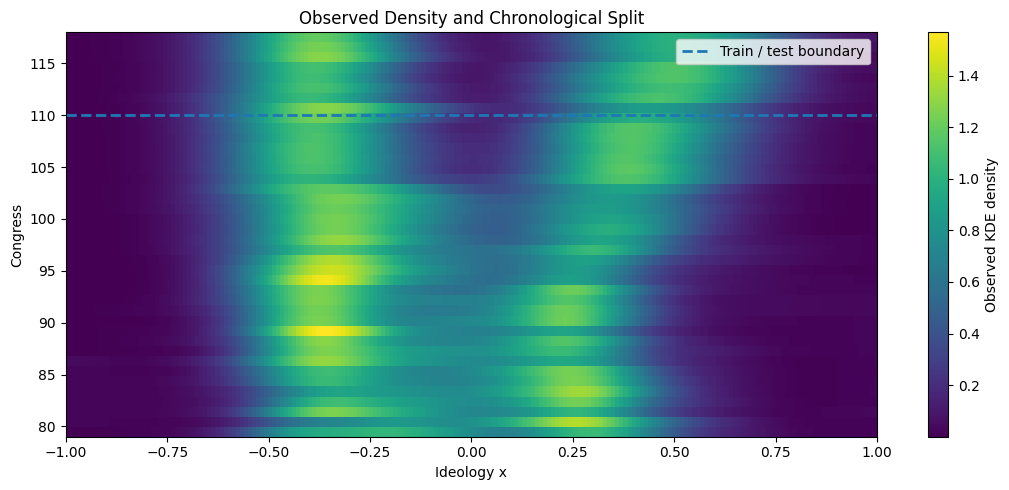

In [10]:
plt.figure(figsize=(11, 5))

plt.imshow(
    p_observed,
    aspect="auto",
    origin="lower",
    extent=[
        x_grid.min(),
        x_grid.max(),
        congresses.min(),
        congresses.max(),
    ],
)

plt.colorbar(label="Observed KDE density")

plt.axhline(
    forecast_start_congress,
    linestyle="--",
    linewidth=2,
    label="Train / test boundary",
)

plt.xlabel("Ideology x")
plt.ylabel("Congress")
plt.title("Observed Density and Chronological Split")
plt.legend()

plt.tight_layout()
plt.show()

In [11]:
def to_tensor(array, requires_grad=False):
    return torch.tensor(
        array,
        dtype=torch.float32,
        device=device,
        requires_grad=requires_grad,
    )


def derivative(
    output,
    input_tensor,
):
    """
    Compute d(output)/d(input_tensor)
    using PyTorch automatic differentiation.
    """
    gradient = torch.autograd.grad(
        outputs=output,
        inputs=input_tensor,
        grad_outputs=torch.ones_like(output),
        create_graph=True,
        retain_graph=True,
        allow_unused=False,
    )[0]

    return gradient


class MLP(nn.Module):
    def __init__(
        self,
        input_dim,
        output_dim=1,
        hidden_width=64,
        hidden_depth=4,
    ):
        super().__init__()

        layers = []

        layers.append(
            nn.Linear(
                input_dim,
                hidden_width,
            )
        )
        layers.append(nn.Tanh())

        for _ in range(hidden_depth - 1):
            layers.append(
                nn.Linear(
                    hidden_width,
                    hidden_width,
                )
            )
            layers.append(nn.Tanh())

        layers.append(
            nn.Linear(
                hidden_width,
                output_dim,
            )
        )

        self.network = nn.Sequential(*layers)

        self._initialize()

    def _initialize(self):
        for module in self.modules():
            if isinstance(module, nn.Linear):
                nn.init.xavier_normal_(module.weight)
                nn.init.zeros_(module.bias)

    def forward(self, inputs):
        return self.network(inputs)


class DensityNet(nn.Module):
    """
    Positive neural density p_theta(t,x).

    Positivity is imposed by softplus.
    Normalization is imposed through a separate mass loss.
    """
    def __init__(
        self,
        hidden_width=64,
        hidden_depth=4,
    ):
        super().__init__()

        self.mlp = MLP(
            input_dim=2,
            output_dim=1,
            hidden_width=hidden_width,
            hidden_depth=hidden_depth,
        )

    def forward(self, t, x):
        inputs = torch.cat(
            [t, x],
            dim=1,
        )

        raw = self.mlp(inputs)

        return F.softplus(raw) + 1e-6


class DriftNet(nn.Module):
    """
    Time-homogeneous vanilla drift b_phi(x).
    """
    def __init__(
        self,
        hidden_width=48,
        hidden_depth=3,
        max_abs_drift=3.0,
    ):
        super().__init__()

        self.mlp = MLP(
            input_dim=1,
            output_dim=1,
            hidden_width=hidden_width,
            hidden_depth=hidden_depth,
        )

        self.max_abs_drift = max_abs_drift

    def forward(self, x):
        raw = self.mlp(x)

        # Smooth bounded output for numerical stability.
        return (
            self.max_abs_drift
            * torch.tanh(raw)
        )

fp residual

In [12]:
def compute_fp_terms(
    density_net,
    drift_net,
    t,
    x,
    D,
):
    """
    Compute:

        p_t
        p_x
        p_xx
        b
        (bp)_x
        FP residual

    for

        p_t + d_x(bp) - D p_xx = 0.
    """
    p = density_net(t, x)
    b = drift_net(x)

    p_t = derivative(
        p,
        t,
    )

    p_x = derivative(
        p,
        x,
    )

    p_xx = derivative(
        p_x,
        x,
    )

    bp = b * p

    bp_x = derivative(
        bp,
        x,
    )

    fp_residual = (
        p_t
        + bp_x
        - D * p_xx
    )

    flux = (
        b * p
        - D * p_x
    )

    return {
        "p": p,
        "b": b,
        "p_t": p_t,
        "p_x": p_x,
        "p_xx": p_xx,
        "bp_x": bp_x,
        "fp_residual": fp_residual,
        "flux": flux,
    }

Learn $p_theta(t,x)$ and time-homogeneous $b_phi(x)$
    using TRAIN densities only.

In [13]:
def train_inverse_fp_pinn(
    t_train,
    x_grid,
    p_train,
    D=0.001,
    epochs=5000,
    learning_rate=1e-3,
    n_data_batch=2048,
    n_collocation=2048,
    n_boundary=256,
    n_mass_times=16,
    print_every=250,
):
    """
    Stage 1:
    Learn p_theta(t,x) and time-homogeneous b_phi(x)
    using TRAIN densities only.

    Loss:
        data fit
        + FP residual
        + initial condition
        + no-flux BC
        + mass normalization
        + drift smoothness
    """
    density_net = DensityNet().to(device)
    drift_net = DriftNet().to(device)

    optimizer = torch.optim.Adam(
        list(density_net.parameters())
        + list(drift_net.parameters()),
        lr=learning_rate,
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=400,
        min_lr=1e-5,
    )

    # Flatten observed train density panel
    time_mesh, x_mesh = np.meshgrid(
        t_train,
        x_grid,
        indexing="ij",
    )

    observed_t = time_mesh.reshape(-1, 1)
    observed_x = x_mesh.reshape(-1, 1)
    observed_p = p_train.reshape(-1, 1)

    observed_t_tensor = to_tensor(observed_t)
    observed_x_tensor = to_tensor(observed_x)
    observed_p_tensor = to_tensor(observed_p)

    t_min = float(np.min(t_train))
    t_max = float(np.max(t_train))

    x_min = float(np.min(x_grid))
    x_max = float(np.max(x_grid))

    # Initial condition is first train Congress
    initial_t_tensor = to_tensor(
        np.full(
            (len(x_grid), 1),
            t_min,
        )
    )

    initial_x_tensor = to_tensor(
        x_grid.reshape(-1, 1)
    )

    initial_p_tensor = to_tensor(
        p_train[0].reshape(-1, 1)
    )

    # Quadrature grid for normalization
    mass_x = to_tensor(
        x_grid.reshape(-1, 1)
    )

    dx = float(x_grid[1] - x_grid[0])

    history = {
        "total": [],
        "data": [],
        "pde": [],
        "ic": [],
        "bc": [],
        "mass": [],
        "smooth": [],
    }

    best_loss = np.inf
    best_density_state = None
    best_drift_state = None

    n_observed = len(observed_t)

    # Loss weights
    lambda_data = 10.0
    lambda_pde = 1.0
    lambda_ic = 20.0
    lambda_bc = 5.0
    lambda_mass = 10.0
    lambda_smooth = 1e-3

    for epoch in range(1, epochs + 1):
        optimizer.zero_grad()

        # ----------------------------------------------------
        # A. Observed train-data loss
        # ----------------------------------------------------
        batch_size = min(
            n_data_batch,
            n_observed,
        )

        batch_indices = np.random.choice(
            n_observed,
            size=batch_size,
            replace=False,
        )

        t_data = observed_t_tensor[batch_indices]
        x_data = observed_x_tensor[batch_indices]
        p_target = observed_p_tensor[batch_indices]

        p_prediction = density_net(
            t_data,
            x_data,
        )

        loss_data = torch.mean(
            (p_prediction - p_target) ** 2
        )

        # ----------------------------------------------------
        # B. PDE collocation points
        # ----------------------------------------------------
        t_col = (
            t_min
            + (t_max - t_min)
            * torch.rand(
                n_collocation,
                1,
                device=device,
            )
        )
        t_col.requires_grad_(True)

        x_col = (
            x_min
            + (x_max - x_min)
            * torch.rand(
                n_collocation,
                1,
                device=device,
            )
        )
        x_col.requires_grad_(True)

        terms = compute_fp_terms(
            density_net=density_net,
            drift_net=drift_net,
            t=t_col,
            x=x_col,
            D=D,
        )

        loss_pde = torch.mean(
            terms["fp_residual"] ** 2
        )

        # ----------------------------------------------------
        # C. Initial-condition loss
        # ----------------------------------------------------
        p_initial_prediction = density_net(
            initial_t_tensor,
            initial_x_tensor,
        )

        loss_ic = torch.mean(
            (
                p_initial_prediction
                - initial_p_tensor
            ) ** 2
        )

        # ----------------------------------------------------
        # D. No-flux boundary:
        #
        # J = bp - D p_x = 0 at x=-1 and x=1
        # ----------------------------------------------------
        boundary_t = (
            t_min
            + (t_max - t_min)
            * torch.rand(
                n_boundary,
                1,
                device=device,
            )
        )
        boundary_t.requires_grad_(True)

        x_left = torch.full(
            (n_boundary, 1),
            x_min,
            device=device,
            requires_grad=True,
        )

        x_right = torch.full(
            (n_boundary, 1),
            x_max,
            device=device,
            requires_grad=True,
        )

        left_terms = compute_fp_terms(
            density_net,
            drift_net,
            boundary_t,
            x_left,
            D,
        )

        right_terms = compute_fp_terms(
            density_net,
            drift_net,
            boundary_t,
            x_right,
            D,
        )

        loss_bc = (
            torch.mean(
                left_terms["flux"] ** 2
            )
            +
            torch.mean(
                right_terms["flux"] ** 2
            )
        )

        # ----------------------------------------------------
        # E. Density normalization:
        #
        # integral_{-1}^{1} p(t,x) dx = 1
        # ----------------------------------------------------
        selected_times = (
            t_min
            + (t_max - t_min)
            * torch.rand(
                n_mass_times,
                1,
                device=device,
            )
        )

        mass_t = selected_times.repeat_interleave(
            len(x_grid),
            dim=0,
        )

        mass_x_repeated = mass_x.repeat(
            n_mass_times,
            1,
        )

        p_mass = density_net(
            mass_t,
            mass_x_repeated,
        ).reshape(
            n_mass_times,
            len(x_grid),
        )

        # Trapezoid integration along x
        estimated_mass = torch.trapz(
            p_mass,
            dx=dx,
            dim=1,
        )

        loss_mass = torch.mean(
            (estimated_mass - 1.0) ** 2
        )

        # ----------------------------------------------------
        # F. Smoothness regularization for b(x)
        #
        # Penalize b_x^2
        # ----------------------------------------------------
        x_smooth = (
            x_min
            + (x_max - x_min)
            * torch.rand(
                n_collocation,
                1,
                device=device,
            )
        )
        x_smooth.requires_grad_(True)

        b_smooth = drift_net(x_smooth)

        b_x = derivative(
            b_smooth,
            x_smooth,
        )

        loss_smooth = torch.mean(
            b_x**2
        )

        # ----------------------------------------------------
        # Total loss
        # ----------------------------------------------------
        total_loss = (
            lambda_data * loss_data
            + lambda_pde * loss_pde
            + lambda_ic * loss_ic
            + lambda_bc * loss_bc
            + lambda_mass * loss_mass
            + lambda_smooth * loss_smooth
        )

        total_loss.backward()

        torch.nn.utils.clip_grad_norm_(
            list(density_net.parameters())
            + list(drift_net.parameters()),
            max_norm=10.0,
        )

        optimizer.step()
        scheduler.step(total_loss.detach())

        # Record history
        history["total"].append(
            float(total_loss.detach().cpu())
        )
        history["data"].append(
            float(loss_data.detach().cpu())
        )
        history["pde"].append(
            float(loss_pde.detach().cpu())
        )
        history["ic"].append(
            float(loss_ic.detach().cpu())
        )
        history["bc"].append(
            float(loss_bc.detach().cpu())
        )
        history["mass"].append(
            float(loss_mass.detach().cpu())
        )
        history["smooth"].append(
            float(loss_smooth.detach().cpu())
        )

        current_loss = history["total"][-1]

        if current_loss < best_loss:
            best_loss = current_loss

            best_density_state = copy.deepcopy(
                density_net.state_dict()
            )

            best_drift_state = copy.deepcopy(
                drift_net.state_dict()
            )

        if (
            epoch == 1
            or epoch % print_every == 0
            or epoch == epochs
        ):
            print(
                f"Stage 1 | epoch {epoch:5d} | "
                f"total={current_loss:.6e} | "
                f"data={history['data'][-1]:.3e} | "
                f"pde={history['pde'][-1]:.3e} | "
                f"ic={history['ic'][-1]:.3e} | "
                f"bc={history['bc'][-1]:.3e} | "
                f"mass={history['mass'][-1]:.3e}"
            )

    density_net.load_state_dict(
        best_density_state
    )

    drift_net.load_state_dict(
        best_drift_state
    )

    return (
        density_net,
        drift_net,
        history,
    )

In [14]:
D_VALUE = 0.001

train_density_net, learned_drift_net, stage1_history = (
    train_inverse_fp_pinn(
        t_train=t_train,
        x_grid=x_grid,
        p_train=p_train_observed,
        D=D_VALUE,
        epochs=5000,
        learning_rate=1e-3,
        n_data_batch=2048,
        n_collocation=2048,
        n_boundary=256,
        n_mass_times=16,
        print_every=250,
    )
)

Stage 1 | epoch     1 | total=9.239534e+00 | data=2.125e-01 | pde=1.410e-01 | ic=2.044e-01 | bc=2.744e-01 | mass=1.512e-01
Stage 1 | epoch   250 | total=1.158851e+00 | data=6.375e-02 | pde=2.401e-03 | ic=2.571e-02 | bc=7.344e-04 | mass=9.342e-05
Stage 1 | epoch   500 | total=2.350304e-01 | data=1.846e-02 | pde=4.490e-03 | ic=2.166e-03 | bc=2.433e-07 | mass=2.502e-04
Stage 1 | epoch   750 | total=2.424449e-01 | data=1.758e-02 | pde=5.381e-03 | ic=2.282e-03 | bc=9.914e-08 | mass=1.557e-03
Stage 1 | epoch  1000 | total=1.984049e-01 | data=1.576e-02 | pde=7.020e-03 | ic=1.541e-03 | bc=1.277e-06 | mass=2.849e-04
Stage 1 | epoch  1250 | total=2.158152e-01 | data=1.490e-02 | pde=9.086e-03 | ic=1.640e-03 | bc=1.827e-05 | mass=2.479e-03
Stage 1 | epoch  1500 | total=1.852434e-01 | data=1.432e-02 | pde=9.372e-03 | ic=1.132e-03 | bc=7.324e-06 | mass=9.953e-04
Stage 1 | epoch  1750 | total=1.593208e-01 | data=1.382e-02 | pde=8.732e-03 | ic=6.009e-04 | bc=2.232e-05 | mass=1.235e-05
Stage 1 | epoch 

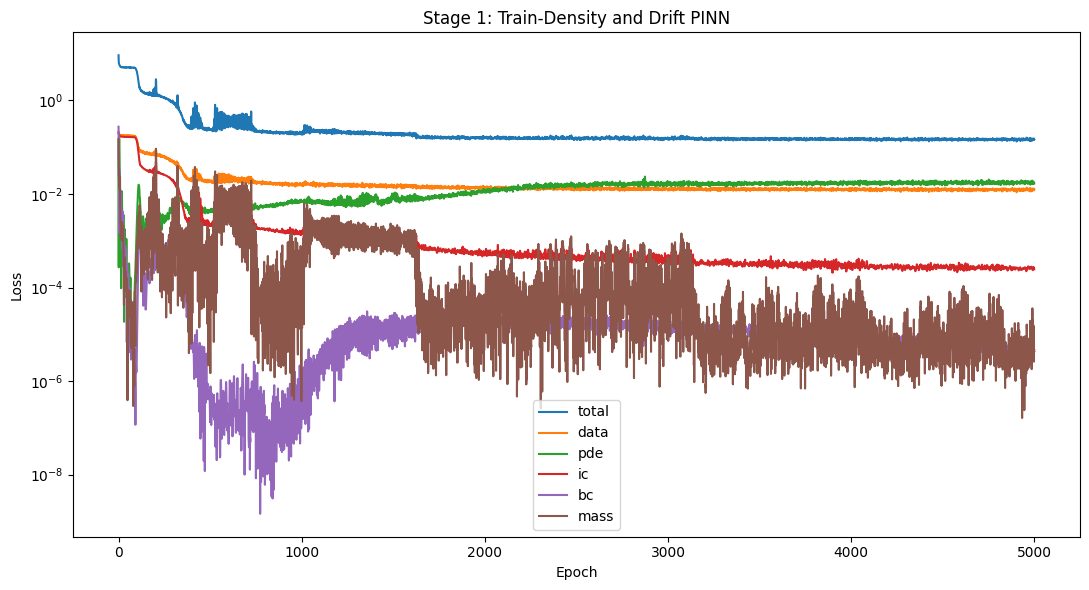

In [15]:
plt.figure(figsize=(11, 6))

for key in [
    "total",
    "data",
    "pde",
    "ic",
    "bc",
    "mass",
]:
    plt.plot(
        stage1_history[key],
        label=key,
    )

plt.yscale("log")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Stage 1: Train-Density and Drift PINN")
plt.legend()
plt.tight_layout()
plt.show()

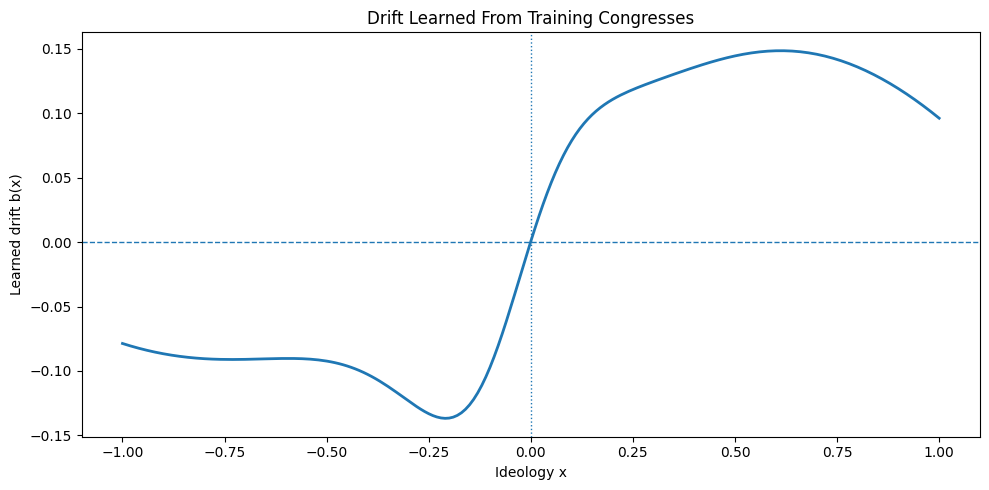

In [16]:
learned_drift_net.eval()

with torch.no_grad():
    x_tensor = to_tensor(
        x_grid.reshape(-1, 1)
    )

    learned_b = (
        learned_drift_net(x_tensor)
        .cpu()
        .numpy()
        .reshape(-1)
    )

plt.figure(figsize=(10, 5))

plt.plot(
    x_grid,
    learned_b,
    linewidth=2,
)

plt.axhline(
    0.0,
    linestyle="--",
    linewidth=1,
)

plt.axvline(
    0.0,
    linestyle=":",
    linewidth=1,
)

plt.xlabel("Ideology x")
plt.ylabel("Learned drift b(x)")
plt.title("Drift Learned From Training Congresses")

plt.tight_layout()
plt.show()

In [17]:
def evaluate_density_net(
    density_net,
    times,
    x_grid,
):
    density_net.eval()

    predicted_rows = []

    with torch.no_grad():
        x_tensor = to_tensor(
            x_grid.reshape(-1, 1)
        )

        for time_value in times:
            t_tensor = torch.full(
                (len(x_grid), 1),
                float(time_value),
                dtype=torch.float32,
                device=device,
            )

            predicted = (
                density_net(
                    t_tensor,
                    x_tensor,
                )
                .cpu()
                .numpy()
                .reshape(-1)
            )

            predicted /= np.trapezoid(
                predicted,
                x_grid,
            )

            predicted_rows.append(predicted)

    return np.vstack(predicted_rows)


p_train_fitted = evaluate_density_net(
    density_net=train_density_net,
    times=t_train,
    x_grid=x_grid,
)

train_mse = np.mean(
    (
        p_train_fitted
        - p_train_observed
    ) ** 2
)

print("Stage 1 train density MSE:", train_mse)

Stage 1 train density MSE: 0.012342762433474307


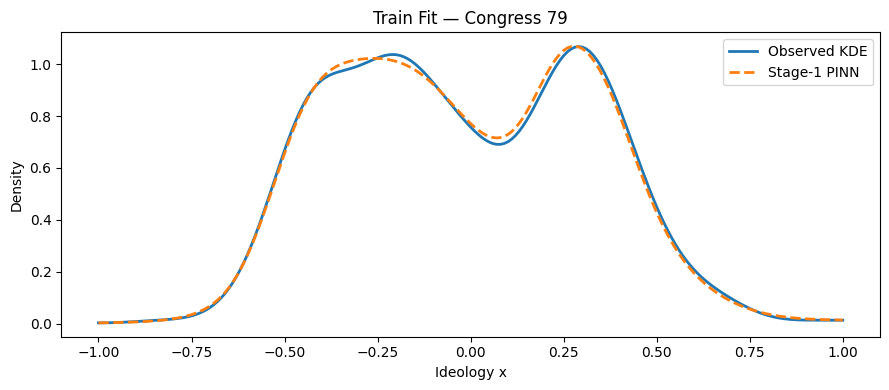

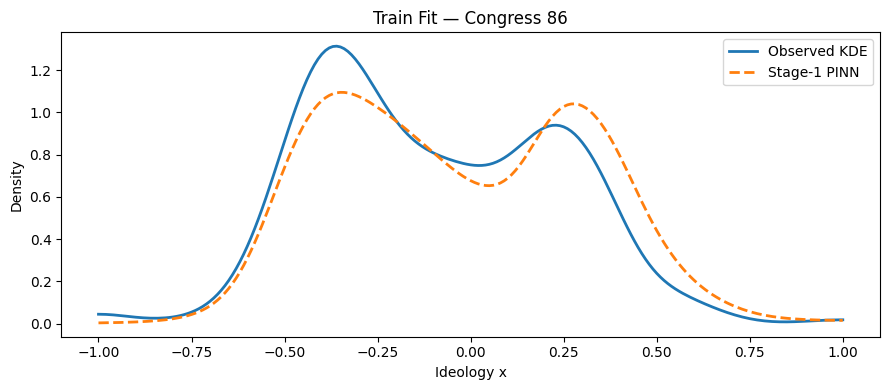

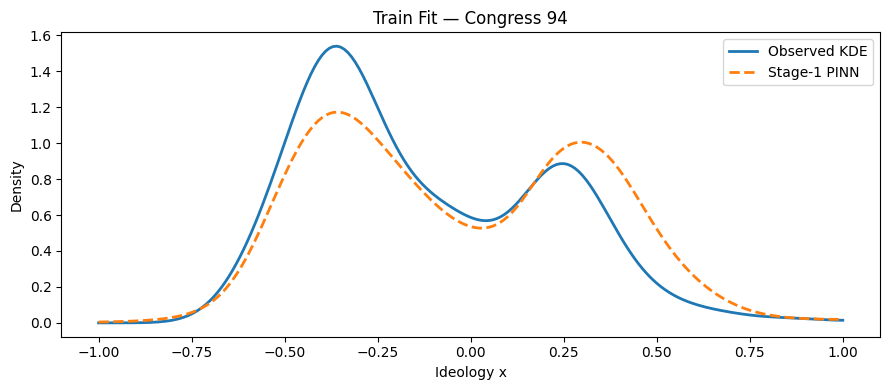

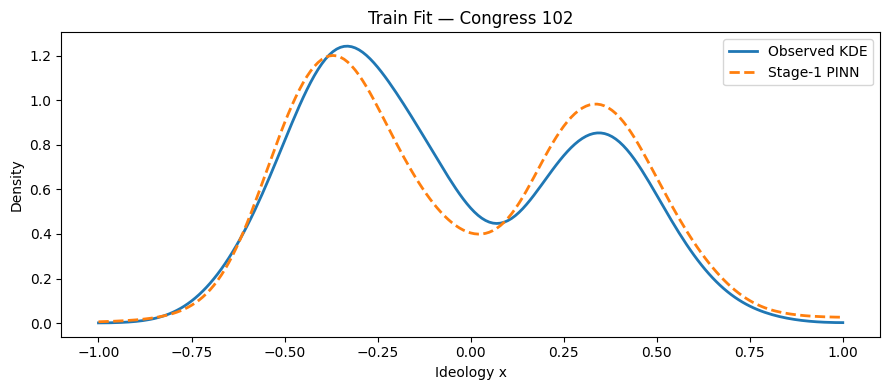

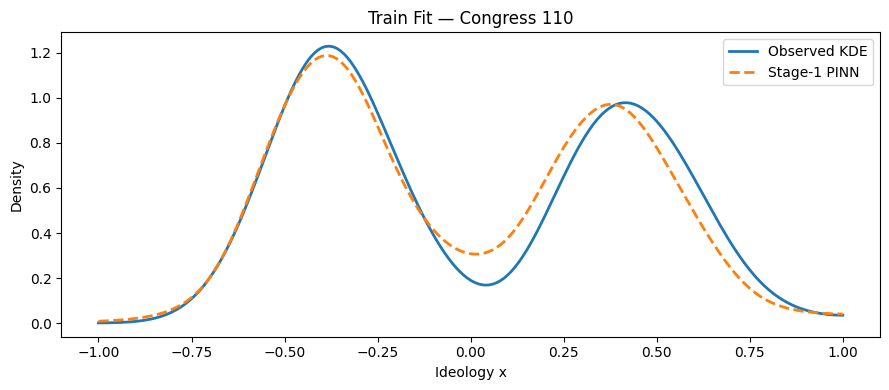

In [18]:
selected_train_indices = np.linspace(
    0,
    len(train_congresses) - 1,
    min(5, len(train_congresses)),
    dtype=int,
)

for local_index in selected_train_indices:
    plt.figure(figsize=(9, 4))

    plt.plot(
        x_grid,
        p_train_observed[local_index],
        linewidth=2,
        label="Observed KDE",
    )

    plt.plot(
        x_grid,
        p_train_fitted[local_index],
        linestyle="--",
        linewidth=2,
        label="Stage-1 PINN",
    )

    plt.xlabel("Ideology x")
    plt.ylabel("Density")
    plt.title(
        f"Train Fit — Congress "
        f"{train_congresses[local_index]}"
    )
    plt.legend()
    plt.tight_layout()
    plt.show()

validation using test data

In [19]:
def train_forward_fp_pinn(
    drift_net,
    forecast_start_time,
    forecast_end_time,
    x_grid,
    initial_density,
    D=0.001,
    epochs=5000,
    learning_rate=1e-3,
    n_collocation=2048,
    n_boundary=256,
    n_mass_times=16,
    print_every=250,
):
    """
    Stage 2:
    Freeze learned b(x), then solve the FP equation forward:

        p_t + d_x(b p) - D p_xx = 0

    over [forecast_start_time, forecast_end_time].

    No test density is used in training.
    """
    forward_density_net = DensityNet().to(device)

    # Freeze drift
    drift_net.eval()

    for parameter in drift_net.parameters():
        parameter.requires_grad_(False)

    optimizer = torch.optim.Adam(
        forward_density_net.parameters(),
        lr=learning_rate,
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=400,
        min_lr=1e-5,
    )

    x_min = float(np.min(x_grid))
    x_max = float(np.max(x_grid))

    t_min = float(forecast_start_time)
    t_max = float(forecast_end_time)

    initial_t_tensor = to_tensor(
        np.full(
            (len(x_grid), 1),
            t_min,
        )
    )

    initial_x_tensor = to_tensor(
        x_grid.reshape(-1, 1)
    )

    initial_p_tensor = to_tensor(
        initial_density.reshape(-1, 1)
    )

    mass_x = to_tensor(
        x_grid.reshape(-1, 1)
    )

    dx = float(x_grid[1] - x_grid[0])

    history = {
        "total": [],
        "pde": [],
        "ic": [],
        "bc": [],
        "mass": [],
    }

    best_loss = np.inf
    best_state = None

    lambda_pde = 1.0
    lambda_ic = 50.0
    lambda_bc = 10.0
    lambda_mass = 20.0

    for epoch in range(1, epochs + 1):
        optimizer.zero_grad()

        # ----------------------------------------------------
        # A. PDE collocation over the forecast horizon
        # ----------------------------------------------------
        t_col = (
            t_min
            + (t_max - t_min)
            * torch.rand(
                n_collocation,
                1,
                device=device,
            )
        )
        t_col.requires_grad_(True)

        x_col = (
            x_min
            + (x_max - x_min)
            * torch.rand(
                n_collocation,
                1,
                device=device,
            )
        )
        x_col.requires_grad_(True)

        terms = compute_fp_terms(
            density_net=forward_density_net,
            drift_net=drift_net,
            t=t_col,
            x=x_col,
            D=D,
        )

        loss_pde = torch.mean(
            terms["fp_residual"] ** 2
        )

        # ----------------------------------------------------
        # B. Initial condition at last train Congress
        # ----------------------------------------------------
        p_initial_prediction = forward_density_net(
            initial_t_tensor,
            initial_x_tensor,
        )

        loss_ic = torch.mean(
            (
                p_initial_prediction
                - initial_p_tensor
            ) ** 2
        )

        # ----------------------------------------------------
        # C. No-flux boundary condition
        # ----------------------------------------------------
        boundary_t = (
            t_min
            + (t_max - t_min)
            * torch.rand(
                n_boundary,
                1,
                device=device,
            )
        )
        boundary_t.requires_grad_(True)

        x_left = torch.full(
            (n_boundary, 1),
            x_min,
            device=device,
            requires_grad=True,
        )

        x_right = torch.full(
            (n_boundary, 1),
            x_max,
            device=device,
            requires_grad=True,
        )

        left_terms = compute_fp_terms(
            forward_density_net,
            drift_net,
            boundary_t,
            x_left,
            D,
        )

        right_terms = compute_fp_terms(
            forward_density_net,
            drift_net,
            boundary_t,
            x_right,
            D,
        )

        loss_bc = (
            torch.mean(
                left_terms["flux"] ** 2
            )
            +
            torch.mean(
                right_terms["flux"] ** 2
            )
        )

        # ----------------------------------------------------
        # D. Mass normalization
        # ----------------------------------------------------
        selected_times = (
            t_min
            + (t_max - t_min)
            * torch.rand(
                n_mass_times,
                1,
                device=device,
            )
        )

        mass_t = selected_times.repeat_interleave(
            len(x_grid),
            dim=0,
        )

        mass_x_repeated = mass_x.repeat(
            n_mass_times,
            1,
        )

        p_mass = forward_density_net(
            mass_t,
            mass_x_repeated,
        ).reshape(
            n_mass_times,
            len(x_grid),
        )

        estimated_mass = torch.trapz(
            p_mass,
            dx=dx,
            dim=1,
        )

        loss_mass = torch.mean(
            (estimated_mass - 1.0) ** 2
        )

        total_loss = (
            lambda_pde * loss_pde
            + lambda_ic * loss_ic
            + lambda_bc * loss_bc
            + lambda_mass * loss_mass
        )

        total_loss.backward()

        torch.nn.utils.clip_grad_norm_(
            forward_density_net.parameters(),
            max_norm=10.0,
        )

        optimizer.step()
        scheduler.step(total_loss.detach())

        history["total"].append(
            float(total_loss.detach().cpu())
        )
        history["pde"].append(
            float(loss_pde.detach().cpu())
        )
        history["ic"].append(
            float(loss_ic.detach().cpu())
        )
        history["bc"].append(
            float(loss_bc.detach().cpu())
        )
        history["mass"].append(
            float(loss_mass.detach().cpu())
        )

        current_loss = history["total"][-1]

        if current_loss < best_loss:
            best_loss = current_loss
            best_state = copy.deepcopy(
                forward_density_net.state_dict()
            )

        if (
            epoch == 1
            or epoch % print_every == 0
            or epoch == epochs
        ):
            print(
                f"Stage 2 | epoch {epoch:5d} | "
                f"total={current_loss:.6e} | "
                f"pde={history['pde'][-1]:.3e} | "
                f"ic={history['ic'][-1]:.3e} | "
                f"bc={history['bc'][-1]:.3e} | "
                f"mass={history['mass'][-1]:.3e}"
            )

    forward_density_net.load_state_dict(
        best_state
    )

    return forward_density_net, history

In [20]:
initial_forward_density = (
    p_observed[forecast_start_index]
)

forecast_end_time = float(
    t_all[-1]
)

forward_density_net, stage2_history = (
    train_forward_fp_pinn(
        drift_net=learned_drift_net,
        forecast_start_time=forecast_start_time,
        forecast_end_time=forecast_end_time,
        x_grid=x_grid,
        initial_density=initial_forward_density,
        D=D_VALUE,
        epochs=5000,
        learning_rate=1e-3,
        n_collocation=2048,
        n_boundary=256,
        n_mass_times=16,
        print_every=250,
    )
)

Stage 2 | epoch     1 | total=8.000232e+00 | pde=4.130e-02 | ic=1.581e-01 | bc=4.800e-03 | mass=4.034e-04
Stage 2 | epoch   250 | total=4.507205e-01 | pde=7.383e-02 | ic=6.907e-03 | bc=1.451e-04 | mass=1.506e-03
Stage 2 | epoch   500 | total=9.238477e-02 | pde=4.107e-02 | ic=4.721e-04 | bc=3.463e-05 | mass=1.368e-03
Stage 2 | epoch   750 | total=9.274220e-02 | pde=2.407e-02 | ic=8.682e-04 | bc=2.167e-05 | mass=1.252e-03
Stage 2 | epoch  1000 | total=6.082488e-02 | pde=1.948e-02 | ic=3.549e-04 | bc=2.240e-05 | mass=1.169e-03
Stage 2 | epoch  1250 | total=4.616756e-02 | pde=1.313e-02 | ic=4.216e-04 | bc=1.651e-05 | mass=5.894e-04
Stage 2 | epoch  1500 | total=3.082470e-02 | pde=8.881e-03 | ic=1.974e-04 | bc=1.769e-05 | mass=5.948e-04
Stage 2 | epoch  1750 | total=6.052533e-03 | pde=3.632e-03 | ic=4.438e-05 | bc=1.330e-05 | mass=3.416e-06
Stage 2 | epoch  2000 | total=2.748851e-03 | pde=1.123e-03 | ic=2.966e-05 | bc=1.164e-05 | mass=1.318e-06
Stage 2 | epoch  2250 | total=2.166885e-03 | p

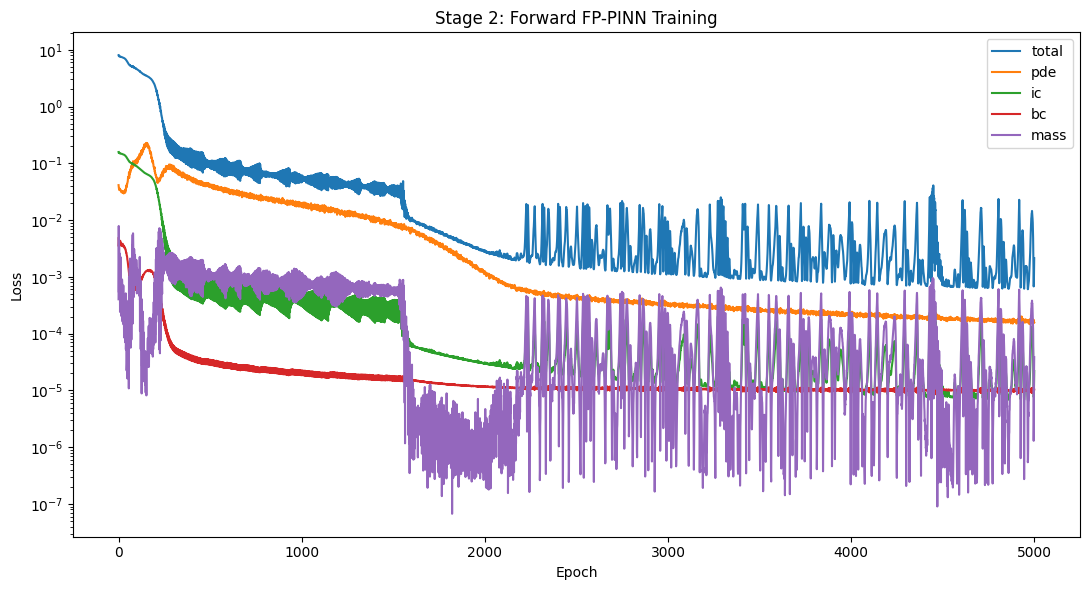

In [21]:
plt.figure(figsize=(11, 6))

for key in [
    "total",
    "pde",
    "ic",
    "bc",
    "mass",
]:
    plt.plot(
        stage2_history[key],
        label=key,
    )

plt.yscale("log")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Stage 2: Forward FP-PINN Training")
plt.legend()
plt.tight_layout()
plt.show()

In [22]:
p_test_predicted = evaluate_density_net(
    density_net=forward_density_net,
    times=t_test,
    x_grid=x_grid,
)

test_mse_by_congress = np.mean(
    (
        p_test_predicted
        - p_test_observed
    ) ** 2,
    axis=1,
)

test_iae_by_congress = np.trapezoid(
    np.abs(
        p_test_predicted
        - p_test_observed
    ),
    x_grid,
    axis=1,
)

test_results = pd.DataFrame({
    "congress": test_congresses,
    "density_mse": test_mse_by_congress,
    "integrated_absolute_error": test_iae_by_congress,
})

display(test_results)

print(
    "\nMean test density MSE:",
    test_results["density_mse"].mean(),
)

print(
    "Mean test integrated absolute error:",
    test_results[
        "integrated_absolute_error"
    ].mean(),
)

,congress,density_mse,integrated_absolute_error
0,111,0.005397,0.102012
1,112,0.014152,0.180667
2,113,0.012449,0.173868
3,114,0.019621,0.213770
4,115,0.016816,0.202455
5,116,0.008319,0.148051
6,117,0.007066,0.139563
7,118,0.008534,0.148167



Mean test density MSE: 0.011544106151972858
Mean test integrated absolute error: 0.16356915544886547


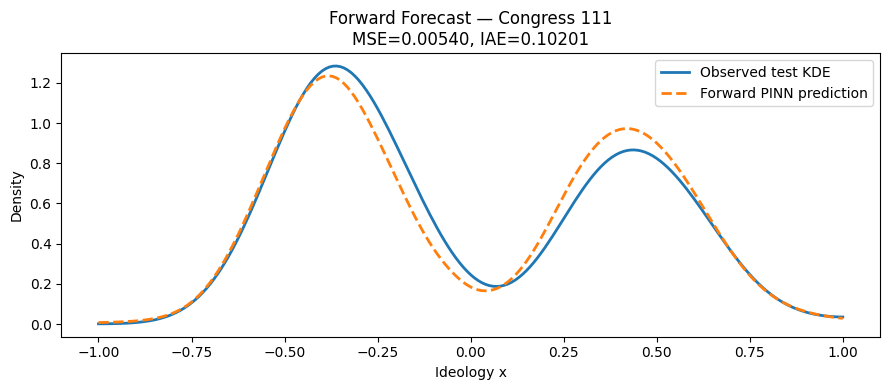

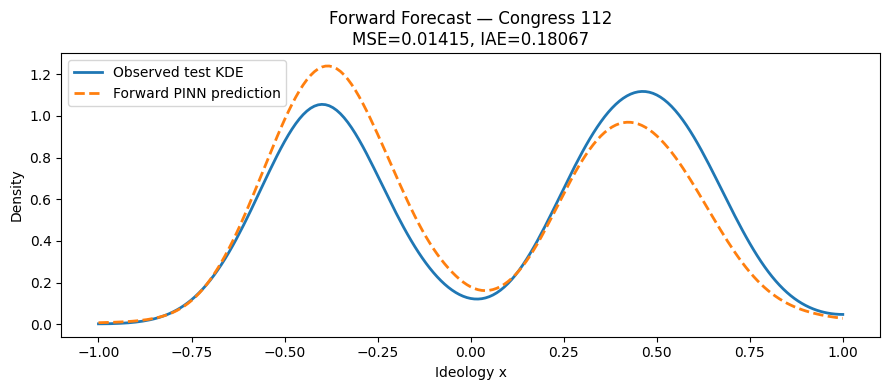

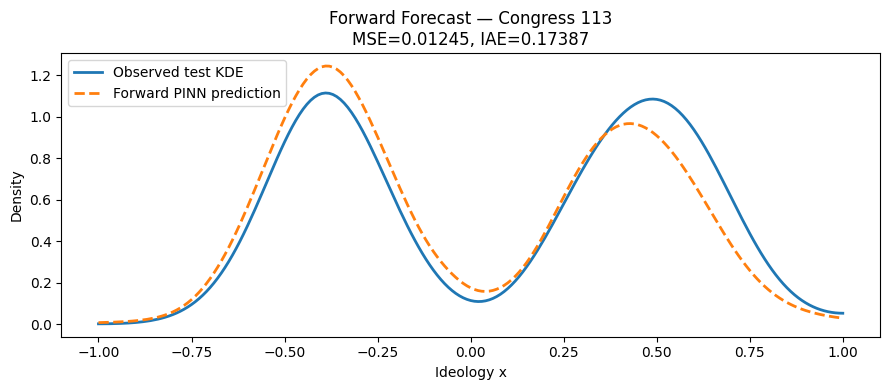

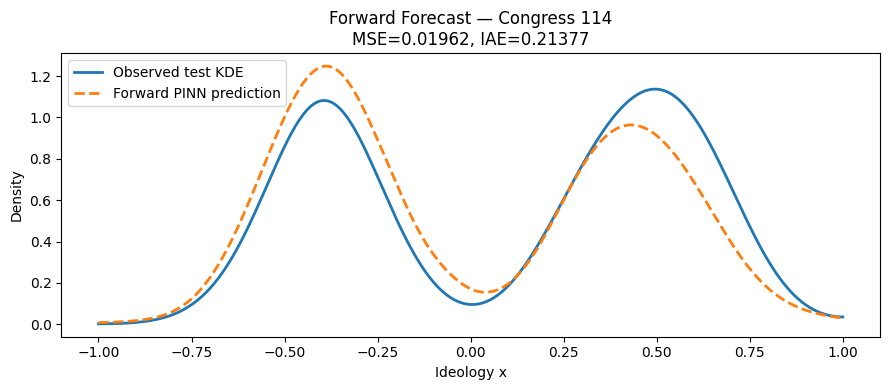

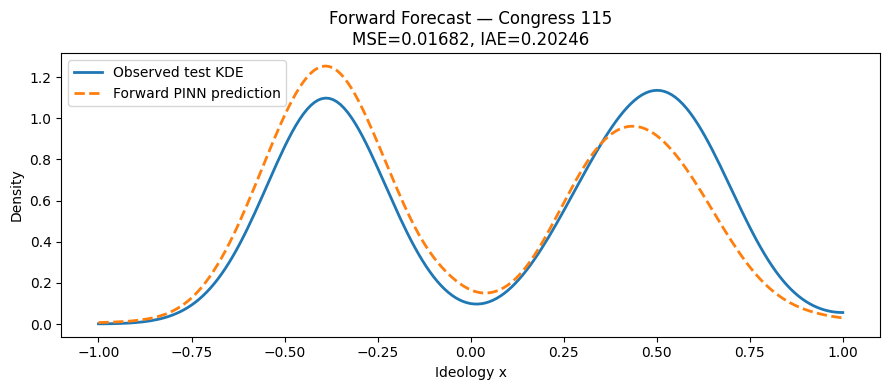

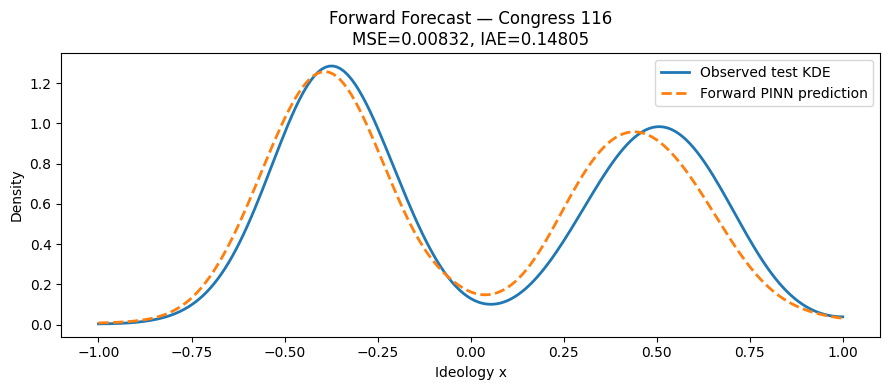

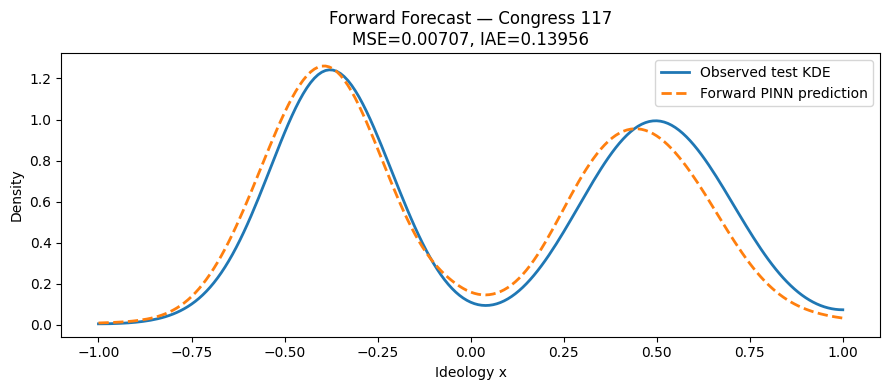

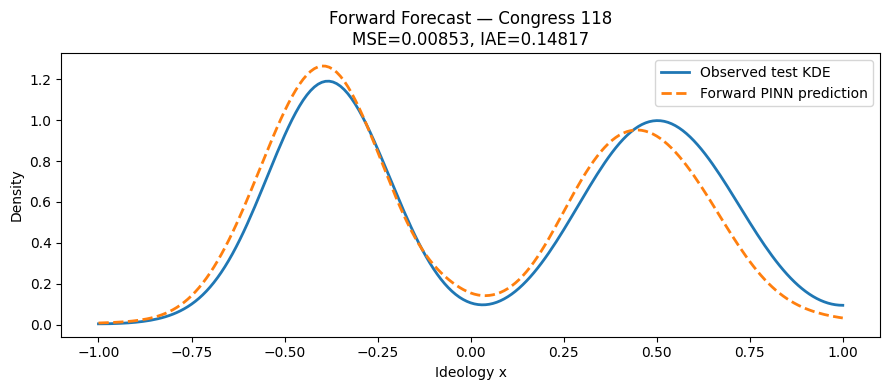

In [23]:
for local_index, congress in enumerate(
    test_congresses
):
    plt.figure(figsize=(9, 4))

    plt.plot(
        x_grid,
        p_test_observed[local_index],
        linewidth=2,
        label="Observed test KDE",
    )

    plt.plot(
        x_grid,
        p_test_predicted[local_index],
        linestyle="--",
        linewidth=2,
        label="Forward PINN prediction",
    )

    plt.xlabel("Ideology x")
    plt.ylabel("Density")

    plt.title(
        f"Forward Forecast — Congress {congress}\n"
        f"MSE={test_mse_by_congress[local_index]:.5f}, "
        f"IAE={test_iae_by_congress[local_index]:.5f}"
    )

    plt.legend()
    plt.tight_layout()
    plt.show()

---

# Part III — Nonlinear / nonlocal Fokker–Planck extension

The linear baseline above assumes a fixed drift field

\[
b=b(x),
\]

so once $b(x)$ is learned, the PDE is linear in the density $p$.

To encode **endogenous ideological interaction**, let the drift depend on the current ideology distribution:

\[
\boxed{
 b[p](t,x)
 = b_{\mathrm{ext}}(x)
 + \int_{-1}^{1} K(x-y)\,p(t,y)\,dy
}
\]

and solve

\[
\boxed{
\partial_t p
+ \partial_x\!\left(b[p]p\right)
- D\,\partial_{xx}p
=0.
}
\]

Interpretation:

- $b_ext(x)$ is a smooth **external ideological force** that depends only on ideological location.
- $K(x-y)$ is a learned **pairwise interaction force**. Because it is constrained to be odd, swapping the relative ordering of two ideological positions reverses the direction of the pairwise force.
- $K(r) > 0$ for $r > 0$ behaves locally like repulsion: a point to the right of other mass is pushed further right.
- $K(r) < 0$ for $r > 0$ behaves locally like attraction: a point to the right of other mass is pulled back toward it.
- The convolution with $p(t,y)$ makes the drift distribution-dependent, which is what makes the forward PDE nonlinear.

For numerical stability and interpretability, this notebook uses a low-dimensional smooth basis rather than an unconstrained neural kernel:

\[
b_{\mathrm{ext}}(x)
= B_{\max}\tanh\!\left(\sum_k c_k P_k(x)\right),
\]

where $P_k$ are Legendre polynomials, and

\[
K(r)
= K_{\max}\tanh\!\left(
\sum_m a_m\,\frac{r}{\ell_m}
\exp\!\left[-\frac12\left(\frac{r}{\ell_m}\right)^2\right]
\right).
\]

The interaction basis is odd by construction, so $K(0)=0$ and $K(-r)=-K(r)$.

In [24]:
# ------------------------------------------------------------
# Nonlinear section bootstrap
# ------------------------------------------------------------
# This makes Part III runnable immediately after the density-panel /
# train-test split cell, even if the expensive linear PINN baseline
# above has not been trained in the current kernel.
import copy
import torch
import torch.nn as nn

if "device" not in globals():
    device = torch.device(
        "cuda" if torch.cuda.is_available() else "cpu"
    )

if "to_tensor" not in globals():
    def to_tensor(array, requires_grad=False):
        return torch.tensor(
            array,
            dtype=torch.float32,
            device=device,
            requires_grad=requires_grad,
        )

D_NONLINEAR = float(
    globals().get("D_VALUE", 0.001)
)

print("Nonlinear FP device:", device)
print("Nonlinear FP diffusion D:", D_NONLINEAR)

# ------------------------------------------------------------
# Prepare the training density panel for inverse nonlinear FP
# ------------------------------------------------------------
# We use the SAME chronological training sample as the linear
# PINN above.  Test Congress densities are not used to estimate
# the nonlinear interaction law.

NONLINEAR_SMOOTH_SIGMA_TIME = 0.75
NONLINEAR_SMOOTH_SIGMA_SPACE = 1.0

p_nl_train = gaussian_filter(
    p_train_observed,
    sigma=(
        NONLINEAR_SMOOTH_SIGMA_TIME,
        NONLINEAR_SMOOTH_SIGMA_SPACE,
    ),
    mode="nearest",
)

p_nl_train = np.maximum(p_nl_train, 0.0)
p_nl_train /= np.trapezoid(
    p_nl_train,
    x_grid,
    axis=1,
)[:, None]

# Numerical derivatives of the observed TRAIN density panel.
p_nl_t = np.gradient(
    p_nl_train,
    t_train,
    axis=0,
    edge_order=2,
)

p_nl_x = np.gradient(
    p_nl_train,
    x_grid,
    axis=1,
    edge_order=2,
)

p_nl_xx = np.gradient(
    p_nl_x,
    x_grid,
    axis=1,
    edge_order=2,
)

print("Nonlinear inverse-fit density shape:", p_nl_train.shape)
print(
    "Training Congresses:",
    int(train_congresses[0]),
    "to",
    int(train_congresses[-1]),
)


Nonlinear FP device: cpu
Nonlinear FP diffusion D: 0.001
Nonlinear inverse-fit density shape: (32, 201)
Training Congresses: 79 to 110


In [25]:
def torch_legendre_basis(x, degree):
    """Return [P_0(x), ..., P_degree(x)] as columns."""
    x = x.reshape(-1)

    columns = [torch.ones_like(x)]

    if degree >= 1:
        columns.append(x)

    for n in range(1, degree):
        next_column = (
            (2 * n + 1) * x * columns[-1]
            - n * columns[-2]
        ) / (n + 1)
        columns.append(next_column)

    return torch.stack(columns, dim=1)


def central_difference_torch(values, dx):
    """Differentiable first derivative along the last dimension."""
    derivative_values = torch.empty_like(values)

    derivative_values[..., 1:-1] = (
        values[..., 2:] - values[..., :-2]
    ) / (2.0 * dx)

    derivative_values[..., 0] = (
        values[..., 1] - values[..., 0]
    ) / dx

    derivative_values[..., -1] = (
        values[..., -1] - values[..., -2]
    ) / dx

    return derivative_values


class NonlinearInteractionFP(nn.Module):
    """
    Smooth distribution-dependent drift

        b[p](x) = b_ext(x) + integral K(x-y) p(y) dy.

    b_ext uses a Legendre basis.
    K uses an odd multi-scale Gaussian-derivative basis.
    """
    def __init__(
        self,
        x_grid,
        external_degree=5,
        interaction_scales=(0.08, 0.15, 0.30, 0.60, 1.20),
        max_external_drift=1.5,
        max_kernel_force=1.5,
    ):
        super().__init__()

        x_np = np.asarray(x_grid, dtype=np.float32)
        x_tensor = torch.tensor(
            x_np,
            dtype=torch.float32,
        )

        external_basis = torch_legendre_basis(
            x_tensor,
            external_degree,
        )

        r = x_tensor[:, None] - x_tensor[None, :]

        kernel_basis = []
        for scale in interaction_scales:
            z = r / float(scale)
            kernel_basis.append(
                z * torch.exp(-0.5 * z ** 2)
            )

        kernel_basis = torch.stack(
            kernel_basis,
            dim=0,
        )

        self.register_buffer(
            "external_basis",
            external_basis,
        )
        self.register_buffer(
            "kernel_basis",
            kernel_basis,
        )

        self.external_raw = nn.Parameter(
            torch.zeros(external_degree + 1)
        )
        self.kernel_raw = nn.Parameter(
            torch.zeros(len(interaction_scales))
        )

        self.max_external_drift = float(max_external_drift)
        self.max_kernel_force = float(max_kernel_force)
        self.interaction_scales = tuple(interaction_scales)

    def external_drift(self):
        raw = self.external_basis @ self.external_raw
        return self.max_external_drift * torch.tanh(raw)

    def kernel_matrix(self):
        raw = torch.einsum(
            "m,mij->ij",
            self.kernel_raw,
            self.kernel_basis,
        )
        return self.max_kernel_force * torch.tanh(raw)

    def drift_from_density(self, density_panel, dx):
        """
        density_panel: (n_times, n_x)
        returns total drift with the same shape.
        """
        b_external = self.external_drift()
        kernel = self.kernel_matrix()

        b_interaction = (
            density_panel @ kernel.T
        ) * dx

        b_total = b_external[None, :] + b_interaction

        return b_total, b_external, b_interaction, kernel


In [26]:
def train_nonlinear_interaction_fp(
    t_train,
    x_grid,
    p_train,
    p_t,
    p_x,
    p_xx,
    D=0.001,
    epochs=3000,
    learning_rate=2e-2,
    external_degree=5,
    interaction_scales=(0.08, 0.15, 0.30, 0.60, 1.20),
    print_every=250,
):
    """
    Estimate the nonlinear drift law from TRAIN densities only.

    The observed density panel is treated as fixed.  We optimize
    the external-force and interaction-kernel coefficients so that

        p_t + d_x(b[p] p) - D p_xx ~= 0

    on the historical training panel, with no-flux and regularization
    penalties.
    """
    dx = float(x_grid[1] - x_grid[0])

    model = NonlinearInteractionFP(
        x_grid=x_grid,
        external_degree=external_degree,
        interaction_scales=interaction_scales,
    ).to(device)

    p_tensor = to_tensor(p_train)
    pt_tensor = to_tensor(p_t)
    px_tensor = to_tensor(p_x)
    pxx_tensor = to_tensor(p_xx)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=learning_rate,
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=300,
        min_lr=1e-4,
    )

    history = {
        "total": [],
        "pde": [],
        "boundary": [],
        "coefficient_reg": [],
        "drift_reg": [],
    }

    best_loss = np.inf
    best_state = None

    # The time derivative is most reliable away from the two
    # chronological endpoints of the training panel.
    interior_time = slice(1, -1)

    lambda_boundary = 5.0
    lambda_coefficient = 2e-4
    lambda_drift = 5e-4

    for epoch in range(1, epochs + 1):
        optimizer.zero_grad()

        (
            b_total,
            b_external,
            b_interaction,
            kernel,
        ) = model.drift_from_density(
            p_tensor,
            dx=dx,
        )

        bp = b_total * p_tensor
        bp_x = central_difference_torch(
            bp,
            dx,
        )

        residual = (
            pt_tensor
            + bp_x
            - D * pxx_tensor
        )

        loss_pde = torch.mean(
            residual[interior_time] ** 2
        )

        # No-flux diagnostic/penalty on the empirical training panel.
        flux_left = (
            b_total[:, 0] * p_tensor[:, 0]
            - D * px_tensor[:, 0]
        )
        flux_right = (
            b_total[:, -1] * p_tensor[:, -1]
            - D * px_tensor[:, -1]
        )

        loss_boundary = (
            torch.mean(flux_left ** 2)
            + torch.mean(flux_right ** 2)
        )

        loss_coefficient = (
            torch.mean(model.external_raw ** 2)
            + torch.mean(model.kernel_raw ** 2)
        )

        loss_drift = torch.mean(
            b_total ** 2
        )

        total_loss = (
            loss_pde
            + lambda_boundary * loss_boundary
            + lambda_coefficient * loss_coefficient
            + lambda_drift * loss_drift
        )

        total_loss.backward()
        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=20.0,
        )
        optimizer.step()
        scheduler.step(total_loss.detach())

        history["total"].append(
            float(total_loss.detach().cpu())
        )
        history["pde"].append(
            float(loss_pde.detach().cpu())
        )
        history["boundary"].append(
            float(loss_boundary.detach().cpu())
        )
        history["coefficient_reg"].append(
            float(loss_coefficient.detach().cpu())
        )
        history["drift_reg"].append(
            float(loss_drift.detach().cpu())
        )

        current_loss = history["total"][-1]
        if current_loss < best_loss:
            best_loss = current_loss
            best_state = copy.deepcopy(
                model.state_dict()
            )

        if (
            epoch == 1
            or epoch % print_every == 0
            or epoch == epochs
        ):
            print(
                f"Nonlinear inverse FP | epoch {epoch:5d} | "
                f"total={current_loss:.6e} | "
                f"pde={history['pde'][-1]:.3e} | "
                f"bc={history['boundary'][-1]:.3e}"
            )

    model.load_state_dict(best_state)
    model.eval()

    return model, history


nonlinear_fp_model, nonlinear_history = train_nonlinear_interaction_fp(
    t_train=t_train,
    x_grid=x_grid,
    p_train=p_nl_train,
    p_t=p_nl_t,
    p_x=p_nl_x,
    p_xx=p_nl_xx,
    D=D_NONLINEAR,
    epochs=3000,
    learning_rate=2e-2,
    external_degree=5,
    interaction_scales=(0.08, 0.15, 0.30, 0.60, 1.20),
    print_every=250,
)


Nonlinear inverse FP | epoch     1 | total=2.046865e+00 | pde=2.047e+00 | bc=6.040e-11
Nonlinear inverse FP | epoch   250 | total=1.861190e+00 | pde=1.860e+00 | bc=2.119e-04
Nonlinear inverse FP | epoch   500 | total=1.856026e+00 | pde=1.855e+00 | bc=1.322e-04
Nonlinear inverse FP | epoch   750 | total=1.854922e+00 | pde=1.854e+00 | bc=1.112e-04
Nonlinear inverse FP | epoch  1000 | total=1.854581e+00 | pde=1.854e+00 | bc=9.582e-05
Nonlinear inverse FP | epoch  1250 | total=1.854446e+00 | pde=1.854e+00 | bc=8.523e-05
Nonlinear inverse FP | epoch  1500 | total=1.854398e+00 | pde=1.854e+00 | bc=8.125e-05
Nonlinear inverse FP | epoch  1750 | total=1.854366e+00 | pde=1.854e+00 | bc=7.875e-05
Nonlinear inverse FP | epoch  2000 | total=1.854347e+00 | pde=1.854e+00 | bc=7.738e-05
Nonlinear inverse FP | epoch  2250 | total=1.854335e+00 | pde=1.854e+00 | bc=7.658e-05
Nonlinear inverse FP | epoch  2500 | total=1.854328e+00 | pde=1.854e+00 | bc=7.613e-05
Nonlinear inverse FP | epoch  2750 | total=

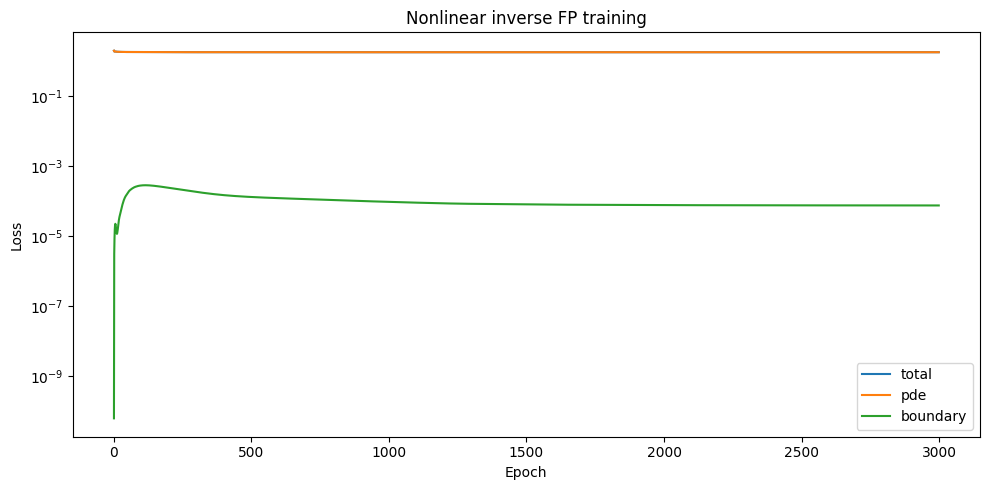

In [27]:
plt.figure(figsize=(10, 5))
for key in ["total", "pde", "boundary"]:
    plt.plot(
        nonlinear_history[key],
        label=key,
    )
plt.yscale("log")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Nonlinear inverse FP training")
plt.legend()
plt.tight_layout()
plt.show()


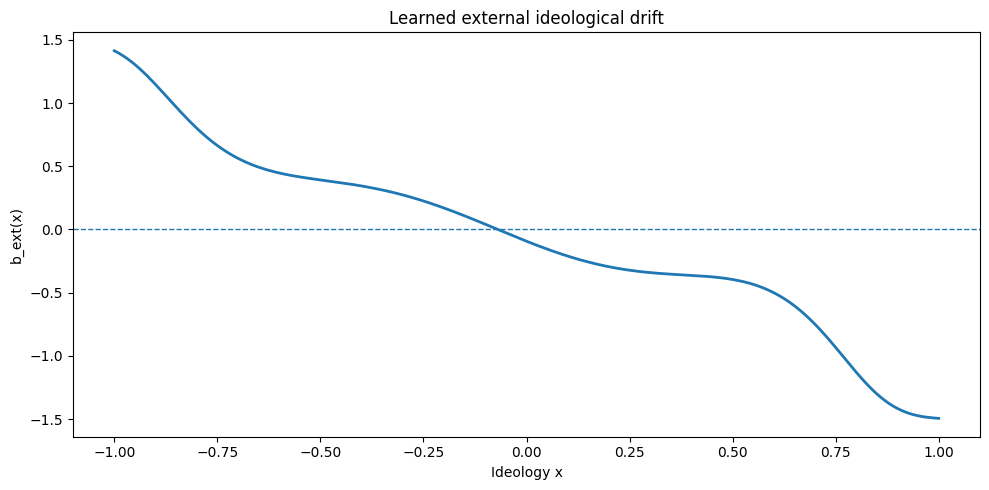

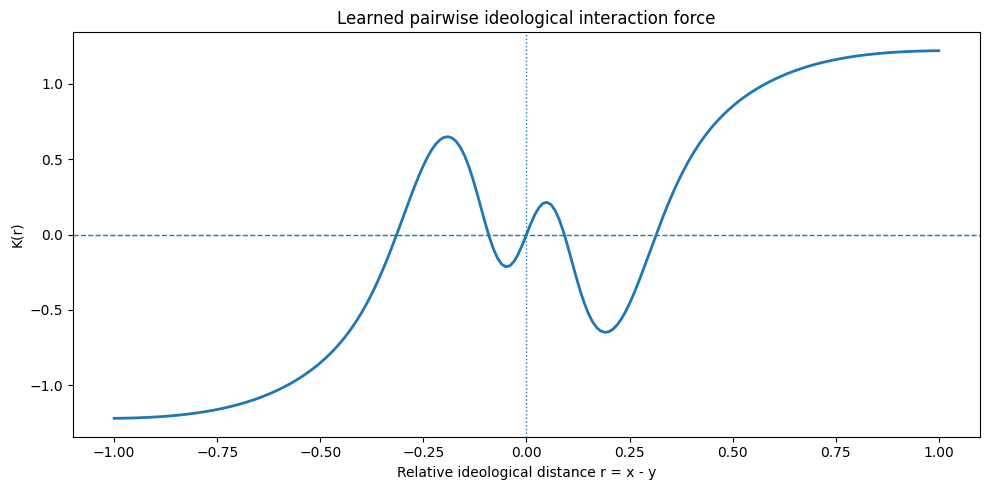

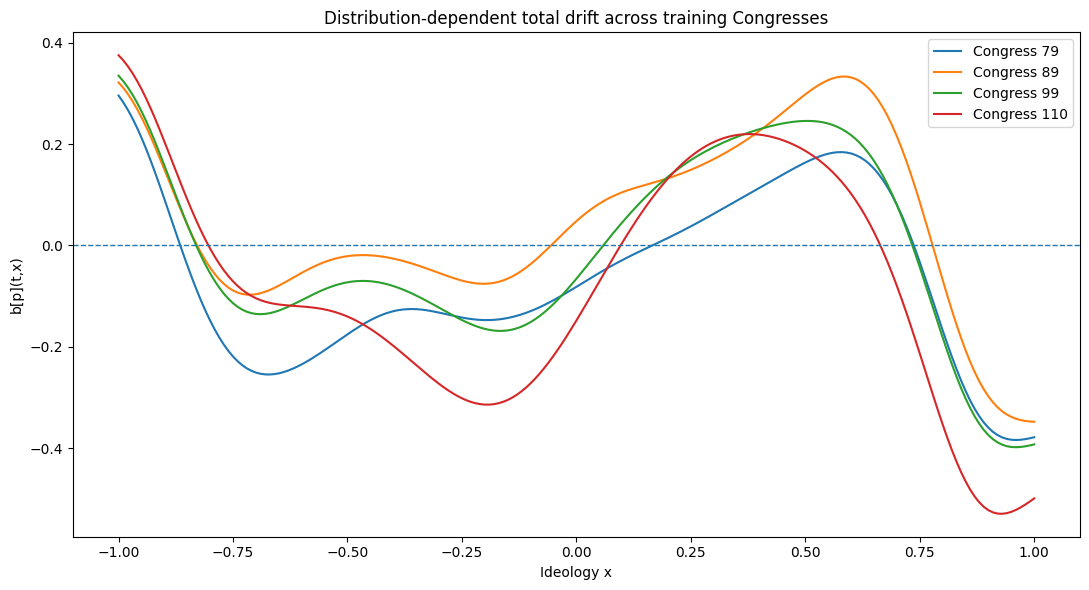

In [28]:
# ------------------------------------------------------------
# Inspect the learned external force, pairwise interaction law,
# and the resulting distribution-dependent drift.
# ------------------------------------------------------------
dx = float(x_grid[1] - x_grid[0])

with torch.no_grad():
    p_train_tensor = to_tensor(p_nl_train)
    (
        b_train_total_t,
        b_external_t,
        b_train_interaction_t,
        kernel_matrix_t,
    ) = nonlinear_fp_model.drift_from_density(
        p_train_tensor,
        dx=dx,
    )

b_external = b_external_t.cpu().numpy()
kernel_matrix = kernel_matrix_t.cpu().numpy()
b_train_total = b_train_total_t.cpu().numpy()
b_train_interaction = b_train_interaction_t.cpu().numpy()

# K(r) can be read from the center row because x_center ~= 0.
center_index = int(np.argmin(np.abs(x_grid)))
r_values = x_grid[center_index] - x_grid
K_values = kernel_matrix[center_index]

sort_index = np.argsort(r_values)
r_sorted = r_values[sort_index]
K_sorted = K_values[sort_index]

plt.figure(figsize=(10, 5))
plt.plot(
    x_grid,
    b_external,
    linewidth=2,
)
plt.axhline(0.0, linestyle="--", linewidth=1)
plt.xlabel("Ideology x")
plt.ylabel("b_ext(x)")
plt.title("Learned external ideological drift")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(
    r_sorted,
    K_sorted,
    linewidth=2,
)
plt.axhline(0.0, linestyle="--", linewidth=1)
plt.axvline(0.0, linestyle=":", linewidth=1)
plt.xlabel("Relative ideological distance r = x - y")
plt.ylabel("K(r)")
plt.title("Learned pairwise ideological interaction force")
plt.tight_layout()
plt.show()

selected_indices = np.linspace(
    0,
    len(train_congresses) - 1,
    4,
    dtype=int,
)

plt.figure(figsize=(11, 6))
for idx in selected_indices:
    plt.plot(
        x_grid,
        b_train_total[idx],
        label=f"Congress {int(train_congresses[idx])}",
    )
plt.axhline(0.0, linestyle="--", linewidth=1)
plt.xlabel("Ideology x")
plt.ylabel("b[p](t,x)")
plt.title("Distribution-dependent total drift across training Congresses")
plt.legend()
plt.tight_layout()
plt.show()


## Recover an ideology potential / landscape

The force representation can also be written in potential form.  If

\[
b_{\mathrm{ext}}(x)=-V'(x),
\qquad
K(r)=-W'(r),
\]

then

\[
b[p](t,x)
= -\partial_x\left(V(x)+(W*p)(t,x)\right).
\]

The quantity

\[
V(x)+(W*p)(t,x)
\]

is a literal **distribution-dependent ideology landscape**: the external landscape $V$ is fixed, while the interaction contribution changes whenever the ideological density changes.

The next cell numerically integrates the learned force fields to visualize $V$ and $W$.  Potentials are identifiable only up to an additive constant, so each curve is centered for plotting.

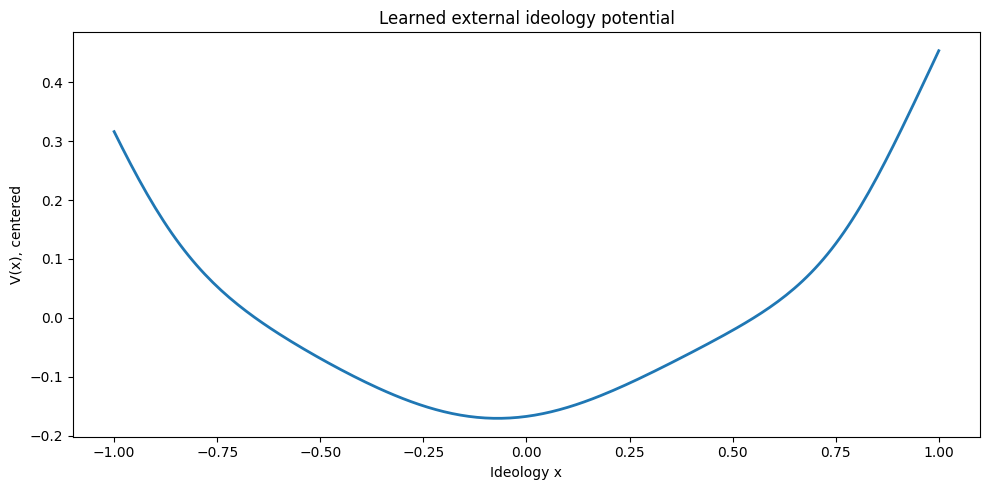

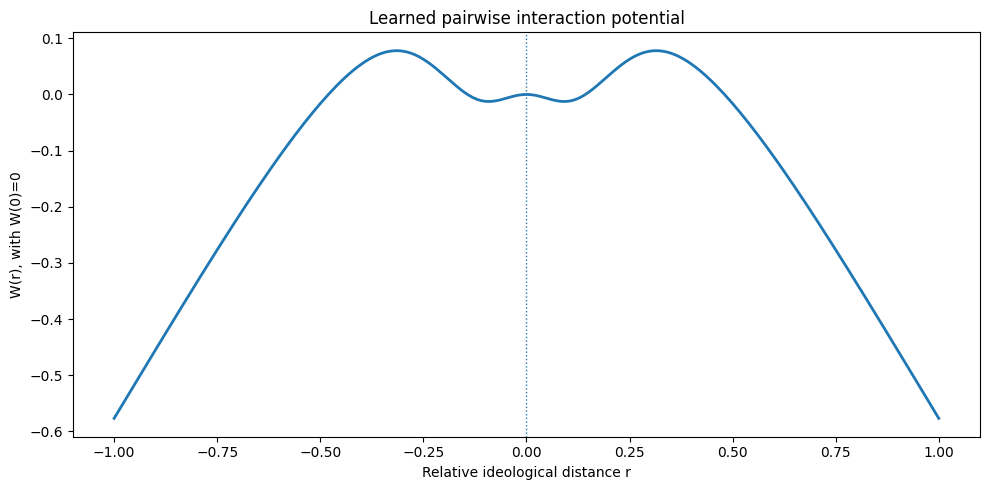

In [29]:
# External potential: V'(x) = -b_ext(x)
V_external = -cumulative_trapezoid(
    b_external,
    x_grid,
    initial=0.0,
)
V_external -= np.mean(V_external)

# Pairwise potential: W'(r) = -K(r)
W_pair = -cumulative_trapezoid(
    K_sorted,
    r_sorted,
    initial=0.0,
)

# Center W so that W(0) = 0 approximately.
zero_r_index = int(np.argmin(np.abs(r_sorted)))
W_pair -= W_pair[zero_r_index]

plt.figure(figsize=(10, 5))
plt.plot(
    x_grid,
    V_external,
    linewidth=2,
)
plt.xlabel("Ideology x")
plt.ylabel("V(x), centered")
plt.title("Learned external ideology potential")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(
    r_sorted,
    W_pair,
    linewidth=2,
)
plt.axvline(0.0, linestyle=":", linewidth=1)
plt.xlabel("Relative ideological distance r")
plt.ylabel("W(r), with W(0)=0")
plt.title("Learned pairwise interaction potential")
plt.tight_layout()
plt.show()


## Stage 2 for the nonlinear model: conservative forward solve

Once `b_ext` and `K` are learned from Congresses 79–110, they are frozen.  Starting from the **observed Congress 110 density**, the nonlinear PDE is solved forward without using Congresses 111–118.

For the forward solve, a finite-volume discretization is preferable to simply extrapolating a neural density function.  The numerical flux is

\[
J=b[p]p-Dp_x,
\qquad
p_t=-\partial_xJ,
\]

with `J=0` imposed at both boundaries.  Advection uses an upwind interface flux and diffusion uses a centered gradient.  An adaptive CFL step keeps the explicit solver stable.


In [30]:
def nonlinear_drift_numpy(
    density,
    b_external,
    kernel_matrix,
    dx,
):
    """Evaluate frozen b[p] for one density vector."""
    interaction = (
        kernel_matrix @ density
    ) * dx

    return b_external + interaction


def nonlinear_fp_rhs_finite_volume(
    density,
    x_grid,
    b_external,
    kernel_matrix,
    D,
):
    """
    Conservative semi-discrete nonlinear FP RHS:

        p_t = -d_x J,
        J = b[p] p - D p_x,

    using upwind advection and centered diffusion at interfaces.
    """
    density = np.asarray(density, dtype=float)
    dx = float(x_grid[1] - x_grid[0])

    b = nonlinear_drift_numpy(
        density,
        b_external,
        kernel_matrix,
        dx,
    )

    b_face = 0.5 * (
        b[:-1] + b[1:]
    )

    p_upwind = np.where(
        b_face >= 0.0,
        density[:-1],
        density[1:],
    )

    advective_flux = b_face * p_upwind
    diffusive_flux = -D * (
        density[1:] - density[:-1]
    ) / dx

    # J has one entry at each cell boundary.
    # No-flux boundaries are imposed exactly by J[0]=J[-1]=0.
    flux = np.zeros(len(density) + 1)
    flux[1:-1] = (
        advective_flux + diffusive_flux
    )

    dp_dt = -(
        flux[1:] - flux[:-1]
    ) / dx

    return dp_dt, b


def advance_nonlinear_fp(
    initial_density,
    start_time,
    target_times,
    x_grid,
    b_external,
    kernel_matrix,
    D,
    cfl=0.35,
    positivity_floor=0.0,
):
    """
    Advance the nonlinear FP equation to each target time using
    an adaptive second-order SSP/RK2 finite-volume method.
    """
    density = np.asarray(
        initial_density,
        dtype=float,
    ).copy()

    density = np.maximum(
        density,
        positivity_floor,
    )
    density /= np.trapezoid(
        density,
        x_grid,
    )

    dx = float(x_grid[1] - x_grid[0])
    current_time = float(start_time)

    predicted_rows = []

    for target_time in target_times:
        target_time = float(target_time)

        if target_time <= current_time:
            raise ValueError(
                "target_times must be strictly after start_time and increasing."
            )

        while current_time < target_time - 1e-12:
            _, b_now = nonlinear_fp_rhs_finite_volume(
                density,
                x_grid,
                b_external,
                kernel_matrix,
                D,
            )

            max_speed = max(
                float(np.max(np.abs(b_now))),
                1e-8,
            )

            # Combined advection + diffusion CFL rate.
            rate = (
                max_speed / dx
                + 2.0 * D / (dx ** 2)
            )

            stable_dt = cfl / max(rate, 1e-12)
            dt = min(
                stable_dt,
                target_time - current_time,
            )

            k1, _ = nonlinear_fp_rhs_finite_volume(
                density,
                x_grid,
                b_external,
                kernel_matrix,
                D,
            )

            stage1 = density + dt * k1
            stage1 = np.maximum(
                stage1,
                positivity_floor,
            )
            stage1 /= np.trapezoid(
                stage1,
                x_grid,
            )

            k2, _ = nonlinear_fp_rhs_finite_volume(
                stage1,
                x_grid,
                b_external,
                kernel_matrix,
                D,
            )

            density = 0.5 * density + 0.5 * (
                stage1 + dt * k2
            )

            density = np.maximum(
                density,
                positivity_floor,
            )
            density /= np.trapezoid(
                density,
                x_grid,
            )

            current_time += dt

        predicted_rows.append(
            density.copy()
        )

    return np.vstack(predicted_rows)


In [31]:
# ------------------------------------------------------------
# Freeze the learned interaction law and forecast Congresses
# 111--118 from the observed final training density.
# ------------------------------------------------------------
initial_nonlinear_density = p_observed[
    forecast_start_index
].copy()

p_test_predicted_nonlinear = advance_nonlinear_fp(
    initial_density=initial_nonlinear_density,
    start_time=forecast_start_time,
    target_times=t_test,
    x_grid=x_grid,
    b_external=b_external,
    kernel_matrix=kernel_matrix,
    D=D_NONLINEAR,
    cfl=0.35,
)

nonlinear_test_mse = np.mean(
    (
        p_test_predicted_nonlinear
        - p_test_observed
    ) ** 2,
    axis=1,
)

nonlinear_test_iae = np.trapezoid(
    np.abs(
        p_test_predicted_nonlinear
        - p_test_observed
    ),
    x_grid,
    axis=1,
)

nonlinear_test_results = pd.DataFrame({
    "congress": test_congresses,
    "nonlinear_density_mse": nonlinear_test_mse,
    "nonlinear_iae": nonlinear_test_iae,
})

display(nonlinear_test_results)

print(
    "Mean nonlinear test density MSE:",
    float(np.mean(nonlinear_test_mse)),
)
print(
    "Mean nonlinear test IAE:",
    float(np.mean(nonlinear_test_iae)),
)


,congress,nonlinear_density_mse,nonlinear_iae
0,111,0.005787,0.107551
1,112,0.013151,0.181097
2,113,0.010871,0.162737
3,114,0.017300,0.214933
4,115,0.015079,0.191050
5,116,0.009209,0.155142
6,117,0.011166,0.156860
7,118,0.015834,0.184229


Mean nonlinear test density MSE: 0.012299675638883194
Mean nonlinear test IAE: 0.16919996656850825


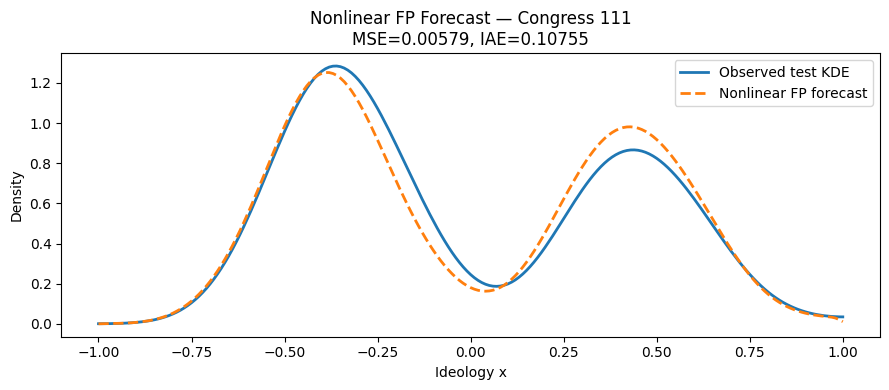

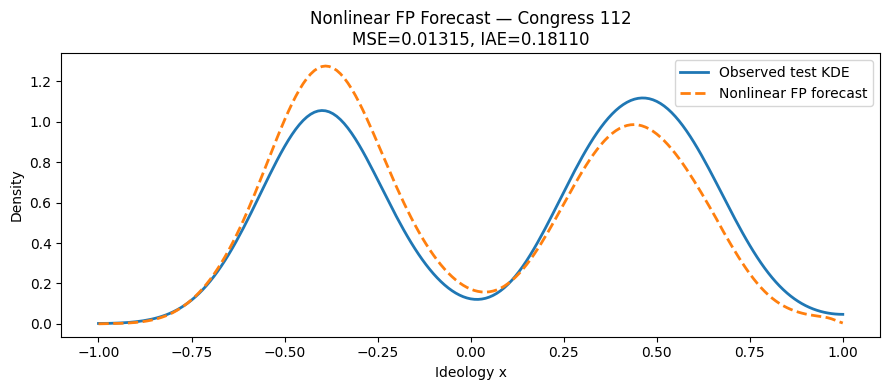

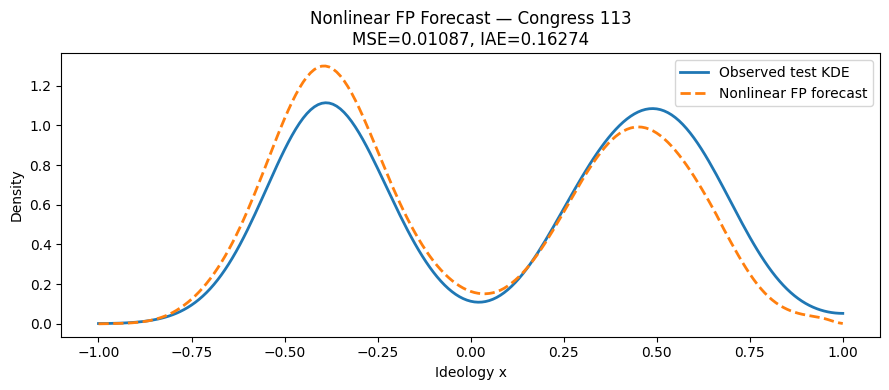

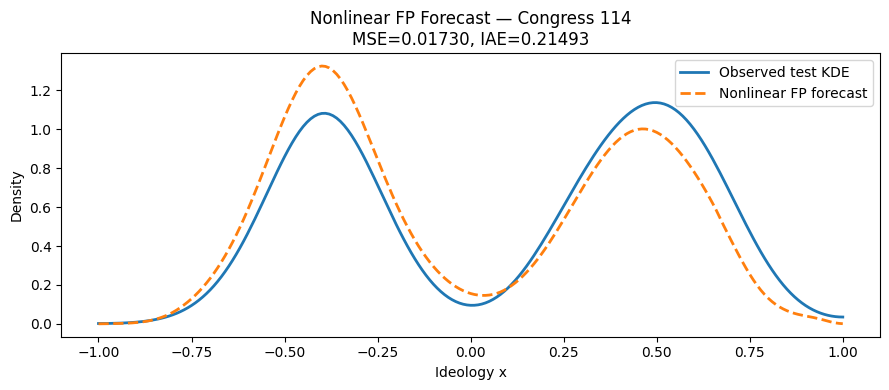

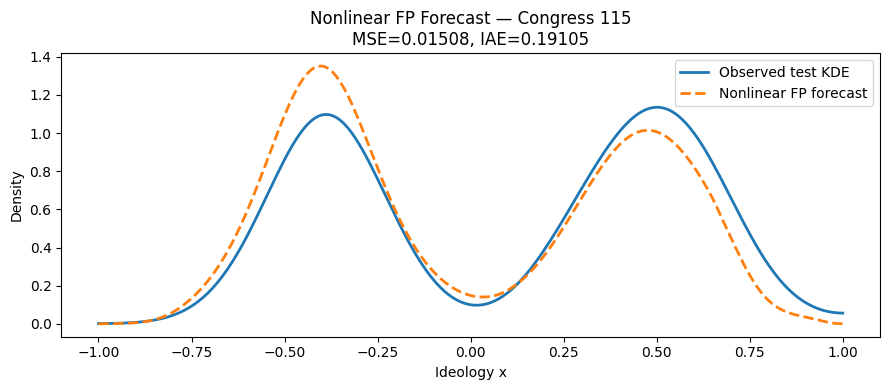

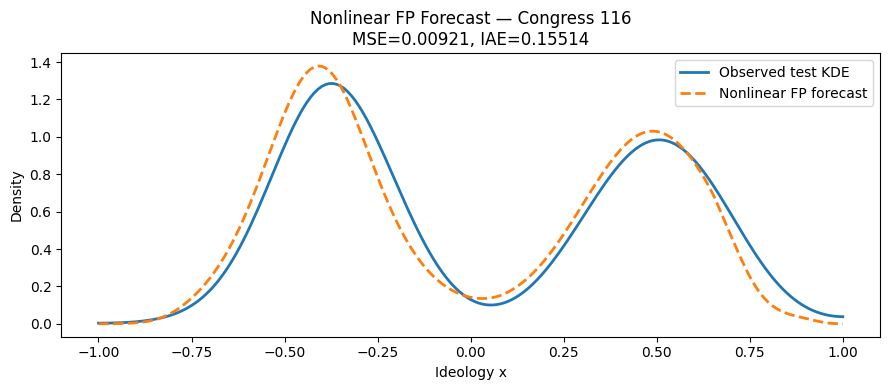

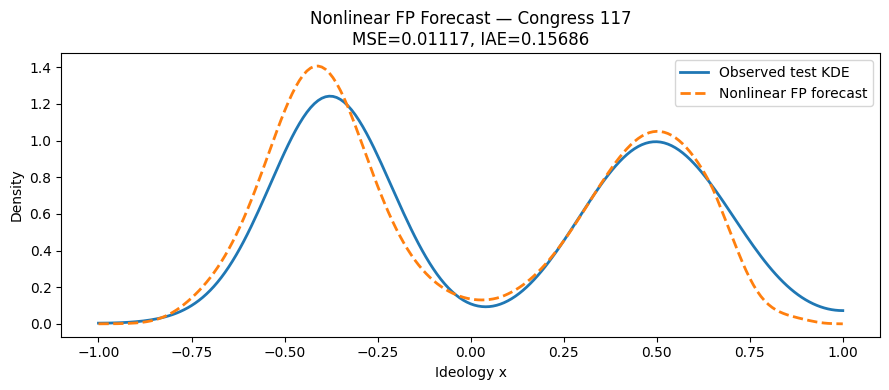

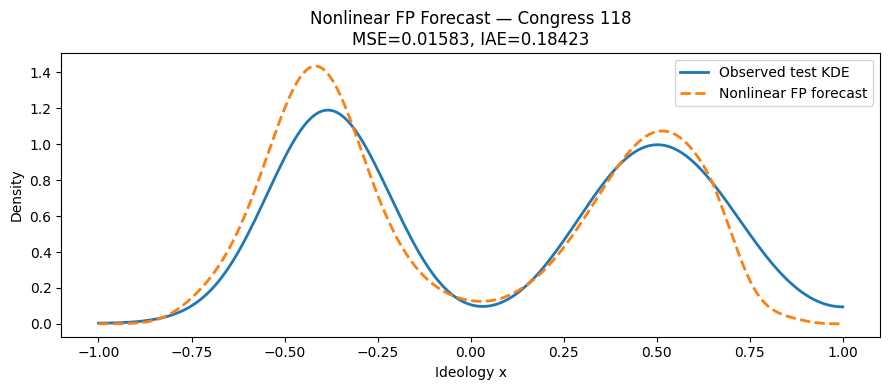

In [32]:
for local_index, congress in enumerate(test_congresses):
    plt.figure(figsize=(9, 4))

    plt.plot(
        x_grid,
        p_test_observed[local_index],
        linewidth=2,
        label="Observed test KDE",
    )

    plt.plot(
        x_grid,
        p_test_predicted_nonlinear[local_index],
        linestyle="--",
        linewidth=2,
        label="Nonlinear FP forecast",
    )

    plt.xlabel("Ideology x")
    plt.ylabel("Density")
    plt.title(
        f"Nonlinear FP Forecast — Congress {int(congress)}\n"
        f"MSE={nonlinear_test_mse[local_index]:.5f}, "
        f"IAE={nonlinear_test_iae[local_index]:.5f}"
    )
    plt.legend()
    plt.tight_layout()
    plt.show()


## Fair out-of-sample comparison

All models below begin from the same Congress 110 observed density and are evaluated on the same held-out Congresses 111–118.

- **Persistence:** assumes the Congress 110 density never changes.
- **Linear FP/PINN:** the baseline model above with fixed $b(x)$.
- **Nonlinear FP:** the new model with distribution-dependent $b[p](t,x)$.

The nonlinear model should only be viewed as an improvement if its held-out errors improve materially and its learned interaction law remains stable/interpretable.  A lower in-sample PDE residual alone is not evidence that the nonlinear mechanism is useful.

In [33]:
# Persistence benchmark: keep the final training density fixed forever.
p_test_persistence = np.repeat(
    initial_nonlinear_density[None, :],
    len(test_congresses),
    axis=0,
)

persistence_mse = np.mean(
    (p_test_persistence - p_test_observed) ** 2,
    axis=1,
)

persistence_iae = np.trapezoid(
    np.abs(p_test_persistence - p_test_observed),
    x_grid,
    axis=1,
)

comparison = pd.DataFrame({
    "congress": test_congresses,
    "persistence_mse": persistence_mse,
    "persistence_iae": persistence_iae,
    "nonlinear_mse": nonlinear_test_mse,
    "nonlinear_iae": nonlinear_test_iae,
})

# If the linear baseline cells above were run, include them automatically.
if "p_test_predicted" in globals():
    comparison["linear_pinn_mse"] = np.mean(
        (p_test_predicted - p_test_observed) ** 2,
        axis=1,
    )
    comparison["linear_pinn_iae"] = np.trapezoid(
        np.abs(p_test_predicted - p_test_observed),
        x_grid,
        axis=1,
    )

ordered_columns = ["congress"]
if "linear_pinn_mse" in comparison.columns:
    ordered_columns += [
        "linear_pinn_mse",
        "nonlinear_mse",
        "persistence_mse",
        "linear_pinn_iae",
        "nonlinear_iae",
        "persistence_iae",
    ]
else:
    ordered_columns += [
        "nonlinear_mse",
        "persistence_mse",
        "nonlinear_iae",
        "persistence_iae",
    ]

comparison = comparison[ordered_columns]
display(comparison)

print("\nMean OOS metrics")
for column in comparison.columns:
    if column != "congress":
        print(
            f"{column:20s}: "
            f"{comparison[column].mean():.6f}"
        )


,congress,linear_pinn_mse,nonlinear_mse,persistence_mse,linear_pinn_iae,nonlinear_iae,persistence_iae
0,111,0.005397,0.005787,0.005185,0.102012,0.107551,0.097757
1,112,0.014152,0.013151,0.015864,0.180667,0.181097,0.186057
2,113,0.012449,0.010871,0.015353,0.173868,0.162737,0.191369
3,114,0.019621,0.017300,0.024201,0.213770,0.214933,0.231590
4,115,0.016816,0.015079,0.022381,0.202455,0.191050,0.231833
5,116,0.008319,0.009209,0.013304,0.148051,0.155142,0.166239
6,117,0.007066,0.011166,0.013132,0.139563,0.156860,0.170090
7,118,0.008534,0.015834,0.016456,0.148167,0.184229,0.198411



Mean OOS metrics
linear_pinn_mse     : 0.011544
nonlinear_mse       : 0.012300
persistence_mse     : 0.015734
linear_pinn_iae     : 0.163569
nonlinear_iae       : 0.169200
persistence_iae     : 0.184168


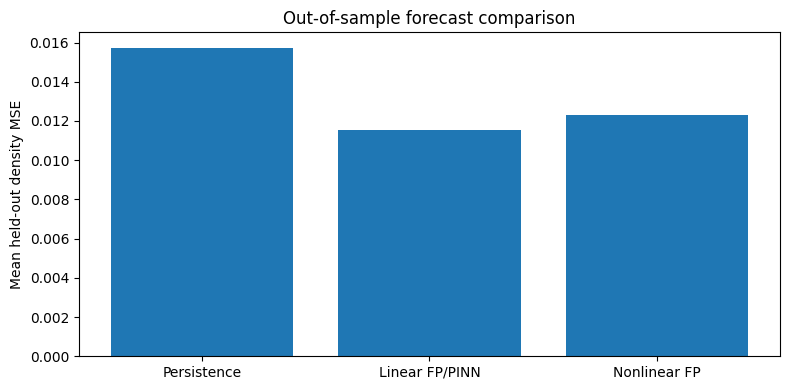

In [34]:
# One summary figure: mean OOS MSE by model.
summary_models = ["Persistence", "Nonlinear FP"]
summary_mse = [
    float(np.mean(persistence_mse)),
    float(np.mean(nonlinear_test_mse)),
]

if "p_test_predicted" in globals():
    summary_models.insert(1, "Linear FP/PINN")
    summary_mse.insert(
        1,
        float(
            np.mean(
                (p_test_predicted - p_test_observed) ** 2
            )
        ),
    )

plt.figure(figsize=(8, 4))
plt.bar(
    summary_models,
    summary_mse,
)
plt.ylabel("Mean held-out density MSE")
plt.title("Out-of-sample forecast comparison")
plt.tight_layout()
plt.show()


## What this nonlinear section adds

The linear model asks:

> **At ideology position $x$, what fixed direction does ideological mass tend to move?**

The nonlinear model asks:

> **At ideology position $x$, how does the direction of motion change when the rest of the ideological population changes?**

That is the direct mathematical link from a measured ideology landscape to a nonlinear Fokker–Planck evolution law.

The complete empirical research chain is therefore

\[
\boxed{
\text{roll-call votes}
\rightarrow X_{i,t}
\rightarrow p_{\mathrm{obs}}(t,x)
\rightarrow \{b_{\mathrm{ext}},K,D\}
\rightarrow \text{nonlinear FP}
\rightarrow \widehat p(t,x)
}
\]

with $D$ held fixed at the same value as the linear baseline in this notebook so that the first comparison isolates the effect of making the drift distribution-dependent.

### Important identification caveat

$b_ext$ and $K$ form an inverse model.  A good historical PDE fit does not prove that the learned force is uniquely identified or causally political.  The held-out forecast, stability across alternative training windows, sensitivity to KDE bandwidth / $D$, and comparison against the linear and persistence baselines are therefore part of the model validation rather than optional diagnostics.

---

# Appendix: original static one-session NOMINATE toy estimator

This appendix is kept only for understanding the mechanics of a simple one-session alternating conditional-MLE routine. It is **not** the longitudinal estimator described in the attached 1D DW-NOMINATE walkthrough and it is not used to create $scores_by_congress$ above.

The attached longitudinal formulation instead estimates each legislator's trajectory coefficients $(chi_i0, chi_i1)$ jointly across sessions and derives $X_it = chi_i0 + chi_i1 T_t1$. The main empirical notebook uses Voteview's precomputed longitudinal $nominate_dim1$ scores as the practical upstream input.

In [35]:
"""
DW-NOMINATE in ONE DIMENSION, single session (static, polynomial degree v=0).
Minimal readable version of the alternating conditional-MLE loop.
  Step 0  starting values : eigenvector (Chapter-2 double-centering) for legislators;
                            simple midpoint rule for roll-call outcomes
  Step 1  utility param   : bounded search for beta   (no weights exist in 1-D)
  Step 2  roll-call params: optimize (O_y,O_n) per roll call, everything else fixed
  Step 3  legislator param: optimize X_i per legislator, everything else fixed
  repeat 1-3 until the log-likelihood stops improving.
"""
import numpy as np
from math import erf
from scipy.optimize import minimize
from scipy.ndimage import gaussian_filter

rng = np.random.default_rng(7)
def Phi(z):
    z=np.asarray(z,float); return 0.5*(1.0+np.vectorize(erf)(z/np.sqrt(2.0)))

N, M = 6, 12
beta_true = 5.0
X_true = np.array([-0.90,-0.55,-0.15,0.20,0.60,0.95])
mid_true = rng.uniform(-0.7,0.7,M); h=0.30
yea_left = rng.random(M)<0.5
Oy_true = np.where(yea_left, mid_true-h, mid_true+h)
On_true = np.where(yea_left, mid_true+h, mid_true-h)
def gap(X,Oy,On,beta): return beta*(np.exp(-0.5*(X-Oy)**2)-np.exp(-0.5*(X-On)**2))
P_yea = Phi(gap(X_true[:,None],Oy_true[None,:],On_true[None,:],beta_true))
V = (rng.random((N,M))<P_yea).astype(int)

def total_loglik(X,Oy,On,beta):
    g=gap(X[:,None],Oy[None,:],On[None,:],beta); p=np.clip(Phi(g),1e-9,1-1e-9)
    return np.sum(np.where(V==1,np.log(p),np.log(1-p)))

# ---- STEP 0 : legislators via Chapter-2 double-centering ----
agree=np.array([[np.mean(V[i]==V[k]) for k in range(N)] for i in range(N)])
D2=(1.0-agree)**2; J=np.eye(N)-np.ones((N,N))/N; B=-0.5*J@D2@J
w,Vec=np.linalg.eigh(B); X=Vec[:,-1]*np.sqrt(max(w[-1],1e-9)); X=X/np.max(np.abs(X))
if np.corrcoef(X,X_true)[0,1]<0: X=-X
X_eigen=X.copy()
Oy=np.zeros(M); On=np.zeros(M)
for j in range(M):
    yv,nv=X[V[:,j]==1],X[V[:,j]==0]
    my=yv.mean() if len(yv) else 0.0; mn=nv.mean() if len(nv) else 0.0
    mid=0.5*(my+mn)
    Oy[j],On[j]=(mid-h,mid+h) if my<mn else (mid+h,mid-h)
beta=5.0

if __name__=="__main__":
    print("Vote matrix (rows=legislators A-F, cols=roll calls 1..%d): 1=Yea 0=Nay"%M)
    print(V,"\n")
    print("STEP 0 eigenvector start X :",np.round(X_eigen,3))
    print("STEP 0 true X              :",np.round(X_true,3))
    print("STEP 0 total logL          : %.3f\n"%total_loglik(X,Oy,On,beta))

    # ---- expanded numbers for Q5: roll call 1 (index 0), Step-2 objective ----
    j=0
    print("=== Q5 detail: STEP 2 objective for roll call 1 (O_y=%.3f O_n=%.3f, beta=5) ==="%(Oy[j],On[j]))
    print(" leg   X_i    u_iy    u_in    gap     P_yea   vote   ln P(obs)")
    tot=0
    for i in range(N):
        uy=beta*np.exp(-0.5*(X[i]-Oy[j])**2); un=beta*np.exp(-0.5*(X[i]-On[j])**2)
        g=uy-un; p=float(np.clip(Phi(g),1e-9,1-1e-9))
        vote=V[i,j]; lnp=np.log(p if vote==1 else 1-p); tot+=lnp
        print("  %s  %+.2f  %6.3f  %6.3f  %+.3f  %5.3f    %d    %7.3f"%("ABCDEF"[i],X[i],uy,un,g,p,vote,lnp))
    print("  roll-call-1 log-likelihood contribution = %.3f\n"%tot)

    # ---- expanded numbers for Q5: legislator A (index 0), Step-3 objective ----
    i=0
    print("=== Q5 detail: STEP 3 objective for legislator A (X=%.3f, beta=5) ==="%X[i])
    print("  rc   O_y     O_n     gap     P_yea   vote   ln P(obs)")
    tot=0
    for j in range(M):
        uy=beta*np.exp(-0.5*(X[i]-Oy[j])**2); un=beta*np.exp(-0.5*(X[i]-On[j])**2)
        g=uy-un; p=float(np.clip(Phi(g),1e-9,1-1e-9))
        vote=V[i,j]; lnp=np.log(p if vote==1 else 1-p); tot+=lnp
        print("  %2d  %+.3f  %+.3f  %+.3f  %5.3f    %d    %7.3f"%(j+1,Oy[j],On[j],g,p,vote,lnp))
    print("  legislator-A log-likelihood contribution = %.3f\n"%tot)

    # ---- run the loop to convergence ----
    for it in range(1,10):
        grid=np.linspace(3.0,7.0,41)
        beta=grid[np.argmax([total_loglik(X,Oy,On,b) for b in grid])]
        for j in range(M):
            def f(o):
                g=gap(X,o[0],o[1],beta); p=np.clip(Phi(g),1e-9,1-1e-9)
                return -np.sum(np.where(V[:,j]==1,np.log(p),np.log(1-p)))
            Oy[j],On[j]=minimize(f,[Oy[j],On[j]],method='Nelder-Mead').x
        for i in range(N):
            def f(x):
                g=gap(x[0],Oy,On,beta); p=np.clip(Phi(g),1e-9,1-1e-9)
                return -np.sum(np.where(V[i]==1,np.log(p),np.log(1-p)))
            X[i]=minimize(f,[X[i]],method='Nelder-Mead').x[0]
        X=X/np.max(np.abs(X))
        if np.corrcoef(X,X_true)[0,1]<0: X=-X
        print("iter %d : beta=%.2f  logL=%.3f  corr(X,true)=%.3f"%(it,beta,total_loglik(X,Oy,On,beta),np.corrcoef(X,X_true)[0,1]))
    print("\nFINAL X :",np.round(X,3))
    print("TRUE  X :",np.round(X_true,3))
    print("START X :",np.round(X_eigen,3))

Vote matrix (rows=legislators A-F, cols=roll calls 1..12): 1=Yea 0=Nay
[[1 1 0 0 0 0 0 0 1 1 0 1]
 [1 1 0 1 0 0 1 0 1 1 1 1]
 [1 1 0 1 1 0 1 0 1 1 0 0]
 [0 1 0 1 1 0 1 1 0 1 1 0]
 [0 0 1 1 1 0 1 1 1 0 1 0]
 [0 0 1 1 1 1 1 1 0 0 1 0]] 

STEP 0 eigenvector start X : [-1.    -0.499 -0.33   0.266  0.611  0.952]
STEP 0 true X              : [-0.9  -0.55 -0.15  0.2   0.6   0.95]
STEP 0 total logL          : -19.118

=== Q5 detail: STEP 2 objective for roll call 1 (O_y=-0.300 O_n=0.300, beta=5) ===
 leg   X_i    u_iy    u_in    gap     P_yea   vote   ln P(obs)
  A  -1.00   3.914   2.148  +1.766  0.961    1     -0.039
  B  -0.50   4.902   3.633  +1.269  0.898    1     -0.108
  C  -0.33   4.998   4.100  +0.898  0.815    1     -0.204
  D  +0.27   4.260   4.997  -0.737  0.231    0     -0.262
  E  +0.61   3.301   4.764  -1.463  0.072    0     -0.075
  F  +0.95   2.283   4.042  -1.759  0.039    0     -0.040
  roll-call-1 log-likelihood contribution = -0.728

=== Q5 detail: STEP 3 objective for legi